# Deep Learning for Natural Language Processing - Exercise 1
#### Author: Margarita Orfanidi Id: 7115152400023

The definition of ambiguity in the responses politicians give during interviews is a very challenging task in the field of NLP. Based on the dataset released for SemEval 2026 Task 6 (CLARITY), this assignment tries to explore this NLP problem and create two classification models. Both models employ Logistic Regression as the underlying classification algorithm but differ in their text representation methods. The first approach represents text using TF-IDF features, while the second utilizes Word2Vec embeddings. The experiments focus on evaluating the performance of each method individually, as well as comparing the two feature extraction techniques within the same classification framework.


# Import the libraries  and Load Dataset

In [11]:
# Libraries 
!pip install contractions wordcloud
!pip install pandas scikit-learn numpy matplotlib seaborn
!pip install pandas matplotlib ipython
!pip install nltk imbalanced-learn pandas emoji contractions wordcloud matplotlib
!pip install scipy gensim scikit-learn 
!pip install nltk
!pip install emoji 
!pip install contractions
import nltk 
!{sys.executable} -m pip install spellchecker
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
!pip install spacy 
!python -m spacy download en_core_web_sm
!python -m spacy download en_core_web_sm
!pip uninstall spellchecker -y
!pip install pyspellchecker

from datasets import load_dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tfidf_functions import *
from w2v_functions import *
from preprocessing_fucntions import *
from helper_functions import *
import random
from gensim.models import KeyedVectors
random.seed(42)
np.random.seed(42)

pd.set_option('display.max_colwidth', None)
# Load the dataset (train and test sets)
dataset = load_dataset("ailsntua/QEvasion")
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Margarita\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Margarita\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Margarita\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Margarita\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ------ --------------------------------- 2.1/12.8 MB 9.5 MB/s eta 0:00:02
     -------------- ------------------------- 4.7/12.8 MB 10.6 MB/s eta 0:00:01
     ---------------------- ----------------- 7.1/12.8 MB 11.0 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 11.2 MB/s eta 0:00:01
     ----------------------------------- --- 11.8/12.8 MB 11.3 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 11.1 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


# Exploratory Data Analysis <br>
As a first step, it is important to explore the dataset in depth in order to better understand the nature and characteristics of the problem we aim to address. Our task is a classification problem focused on response clarity. Specifically, the goal is to classify political responses into predefined categories that reflect the level of clarity or evasiveness present in an answer.

Before proceeding to the modeling stage, it is necessary to perform an initial inspection of the dataset. This exploratory step allows us to examine basic statistics, understand the distribution of the labels, and identify potential patterns that appear in the data. Through this process, we can confirm the structure of the dataset, recognize the most important variables, and develop a clearer understanding of the problem we are attempting to solve. 

## Analysis by Labels and Metadata

### Information
This step helps verify that both train and test sets share the same structure (i.e., they contain the same columns) and allows us to inspect important properties such as the presence of missing values, data types, and the overall size of the datasets (number of entries) before further processing.

In [12]:
# Convert the dataset to pandas DataFrames and display their info
display(df_train.info())
display(df_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3448 entries, 0 to 3447
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  3448 non-null   object
 1   date                   3448 non-null   object
 2   president              3448 non-null   object
 3   url                    3448 non-null   object
 4   question_order         3448 non-null   int64 
 5   interview_question     3448 non-null   object
 6   interview_answer       3448 non-null   object
 7   gpt3.5_summary         3448 non-null   object
 8   gpt3.5_prediction      3448 non-null   object
 9   question               3448 non-null   object
 10  annotator_id           3448 non-null   object
 11  annotator1             0 non-null      object
 12  annotator2             0 non-null      object
 13  annotator3             0 non-null      object
 14  inaudible              3448 non-null   bool  
 15  multiple_questions   

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   title                  0 non-null      object
 1   date                   0 non-null      object
 2   president              0 non-null      object
 3   url                    308 non-null    object
 4   question_order         308 non-null    int64 
 5   interview_question     308 non-null    object
 6   interview_answer       308 non-null    object
 7   gpt3.5_summary         0 non-null      object
 8   gpt3.5_prediction      0 non-null      object
 9   question               308 non-null    object
 10  annotator_id           0 non-null      object
 11  annotator1             308 non-null    object
 12  annotator2             308 non-null    object
 13  annotator3             308 non-null    object
 14  inaudible              308 non-null    bool  
 15  multiple_questions     

None

### Sample display

We displayed random samples from the dataset in order to observe the structure and formatting of the textual data. This qualitative inspection helps identify potential patterns and understand how the text appears in practice, allowing us to draw conclusions about the preprocessing steps that may be required. For example, we observed several spelling inconsistencies and cases where punctuation marks are not properly separated from words due to missing spaces.

In [13]:
# Display random samples of the training set
display_samples(df_train,1)


Sample 2900


,Value
title,"The President's News Conference With President Lee Myung-bak of South Korea at Camp David, Maryland"
date,"April 19, 2008"
president,George W. Bush
url,https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-with-president-lee-myung-bak-south-korea-camp-david
question_order,2
interview_question,"Q. I have a question for President Lee. Korea and the United States have made many achievements through the summit meeting, especially North Korean nuclear issue and the strengthening of the alliance. As for North Korean nuclear issue, Mr. President Lee suggested setting up a permanent liaison office in both Seoul and Pyongyang. What are some of the follow-up effects, if you do have any follow-up actions? And do you have any thoughts of proposing a meeting with Chairman Kim at an earlier date?"
interview_answer,"The process is not something that we discussed between ourselves during the summit meeting. In fact, when I was staying in Washington, DC, I had an interview with one of the newspapers there, and it came up. Of course, it was not a sudden suggestion. I did have a meeting among my staff and related ministries, and I talked about this in detail before I came to the United States.We have a new administration in Korea, and we haven't yet to begun dialogue with the ns. Inter-Korean dialogue, there is a need for us to have dialogue all the time. Up until now, we had dialogues whenever the need arose, and then it would stop. However, dialogue should be based on genuine cooperation and sincerity. And so with this in mind, I thought that it would be helpful to set up a permanent liaison office in both Seoul and Pyongyang.As for the summit meeting between myself and Chairman Kim, I will agree to it when the need is real. And I already said publicly that I am willing to meet with him—not just once, but many times—but if the meeting will yield substantial and real results. I believe only when that is possible, I am ready to meet with him and have sincere dialogue, because that will help to bring about peace and stability of the peninsula.So basically, I do hold that thought, but I'm not suggesting that—to have a meeting with Chairman Kim anytime soon. If the need arises, again, I'm ready to meet with him. Steven Lee [Steven Lee Myers, New York Times]."
gpt3.5_summary,"The question consists of 2 parts:\n\n1. Follow-up effects of setting up a permanent liaison office in Seoul and Pyongyang for the North Korean nuclear issue.\n2. Thoughts on proposing a meeting with Chairman Kim at an earlier date.\n\n<--Summary Answer-->\n\nThe response provides the following information regarding these points:\n\n1. Follow-up effects of setting up a permanent liaison office in Seoul and Pyongyang for the North Korean nuclear issue:\n- President Lee suggests setting up a permanent liaison office in both Seoul and Pyongyang to facilitate dialogue and cooperation between North Korea and South Korea.\n- The suggestion was made during an interview with a newspaper in Washington, DC, and was not discussed during the summit meeting.\n- The intention behind the suggestion is to establish genuine cooperation and sincerity in inter-Korean dialogue.\n\n2. Thoughts on proposing a meeting with Chairman Kim at an earlier date:\n- President Lee is open to the idea of a meeting with Chairman Kim, but only when the need is real and there is a possibility of substantial and real results.\n- He believes that sincere dialogue with Chairman Kim can contribute to the peace and stability of the Korean peninsula.\n- While he holds the thought of meeting with Chairman Kim, he is not suggesting a meeting anytime soon, but is willing to meet if the need arises.\n\nOverall, President Lee emphasizes the importance of genuine cooperation, sincerity, and substantial results in both the setup of a liaison office and the possibility of a meeting with Chairman Kim."
gpt3.5_prediction,"Question 1: Follow-up effects of setting up a permanent liaison office in Se

The responses are labeled based on whether they address each sub-question. As a result, the same response may appear multiple times in the dataset, depending on the number of sub-questions associated with a given interview question.

This behavior is illustrated below by displaying the original question, the corresponding sub-questions, the interview response, and the assigned label. As shown, the same response is repeated across different sub-questions, while the assigned label may vary depending on how well the response addresses each sub-question.

In [14]:
import random
def show_question(df, interview_q):
    subset = df[df['interview_question'] == interview_q]

    print("INTERVIEW QUESTION:")
    print(interview_q)

    for i, row in subset.iterrows():
        print("\n--- Example ---")
        print("Sub-question:")
        print(row['question'])

        print("\nAnswer:")
        print(row['interview_answer'][:300] + "...") 

        print("\nClarity label:", row['clarity_label'])

q = random.choice(df_train['interview_question'].unique())
show_question(df_train, q)

INTERVIEW QUESTION:
Q. And if I could, on the election, sir—can I——TikTok/Microsoft Corporation  Q. President Trump, on the sale of TikTok, you're basically arguing that the U.S. Government is going to collect a cut from a—of a transaction including two companies, in which it doesn't hold a stake in.That's unprecedented. That's never happened in U.S. history before, and the administration has offered very little explanation about how that's going to work. Can you back your statement up and provide specifics about how that would work?

--- Example ---
Sub-question:
The interviewer's request for President Trump to back up his statement and provide specific details on how the government would collect this cut.

Answer:
Did you say, That's impressive? Did you actually use that term?...

Clarity label: Ambivalent

--- Example ---
Sub-question:
The previous comment made by the interviewer, expressing that President Trump is arguing for the U.S. Government to collect a cut from the sale of Ti

### Labels Distribution

#### Clarity Labels Distribution
The labels used for the classification task are the clarity labels, which include Clear Reply, Clear Non-Reply, and Ambivalent. The distribution of instances across these labels is shown below.
The majority of instances belong to the Ambivalent class, accounting for approximately 59.2\% of the data (2039 samples). The Clear Reply category represents about 30.5\% of the dataset (1051 samples), while Clear Non-Reply is the least frequent class with 10.3\% (356 samples).
This distribution indicates a noticeable class imbalance, with the Ambivalent class dominating the dataset, a factor that should be considered during model training and evaluation.

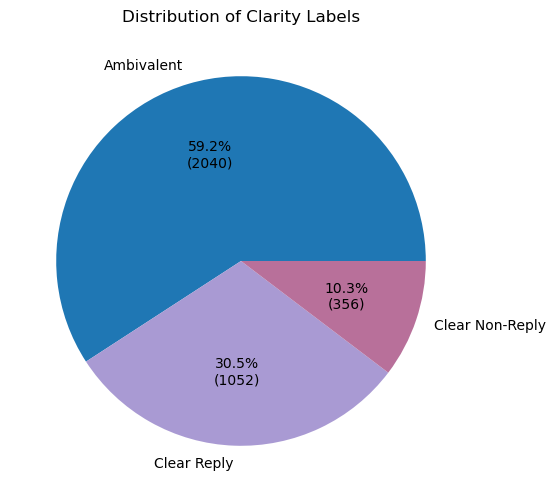

In [15]:

colors = ["#1f77b4", "#a99ad3", "#b8709a"]

df_train["clarity_label"].value_counts().plot(
    kind="pie",
    autopct=lambda p: f"{p:.1f}%\n({int(p*len(df_train)/100)})",
    figsize=(6,6),
    colors=colors
)
plt.title("Distribution of Clarity Labels")
plt.ylabel("")
plt.show()



####  Evasion Labels Distribution

In addition to the clarity labels, the dataset also provides evasion labels, which describe the specific strategies used in the responses.
As shown in the table, the evasion categories include Claims ignorance, Clarification, Declining to answer, Deflection, Dodging, Explicit, General, Implicit, and Partial/Half-answer.
Furthermore, we can observe at the crosstab table how each evasion category corresponds to a particular clarity label in the dataset. For instance, strategies such as Deflection, Dodging, Implicit, General, and Partial/Half-answer appear in responses labeled as Ambivalent, while Claims ignorance, Clarification, and Declining to answer are associated with Clear Non-Reply. Finally, the Explicit category corresponds to the Clear Reply label, indicating a direct and clear response.

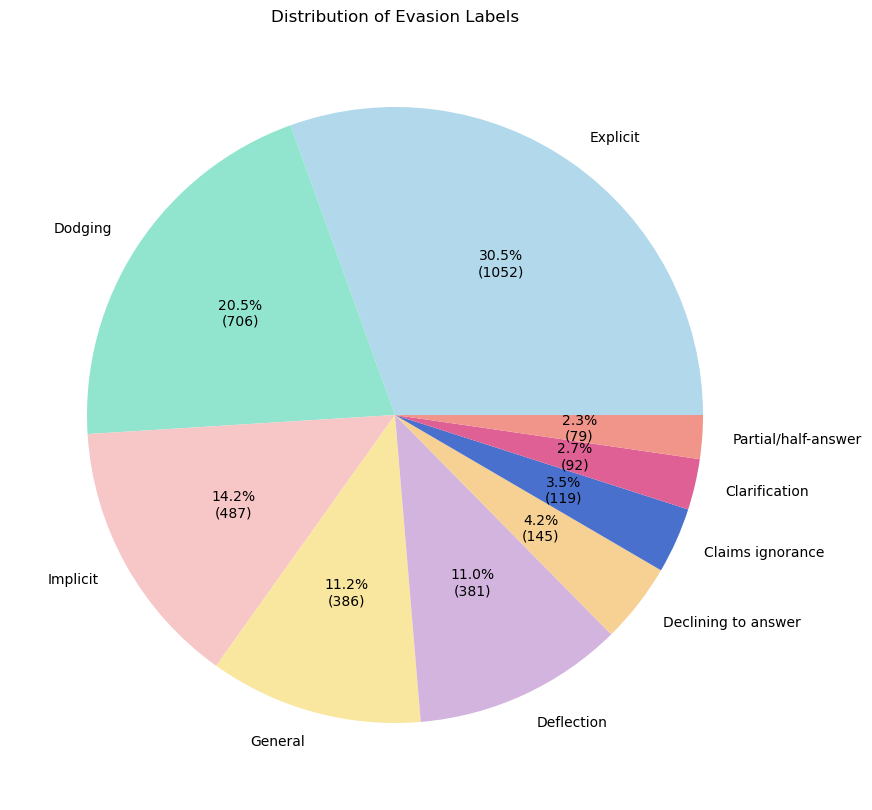

evasion_label,Claims ignorance,Clarification,Declining to answer,Deflection,Dodging,Explicit,General,Implicit,Partial/half-answer
clarity_label,,,,,,,,,
Ambivalent,0,0,0,381,706,0,386,488,79
Clear Non-Reply,119,92,145,0,0,0,0,0,0
Clear Reply,0,0,0,0,0,1052,0,0,0


In [16]:
colors = ["#b1d8eb", "#91e5cf", "#f7c6c7", "#f9e79f", "#d2b4de", "#f7d194", "#4970cd", "#de6095", "#f1948a" ]

df_train["evasion_label"].value_counts().plot(
    kind="pie",
    autopct=lambda p: f"{p:.1f}%\n({int(p*len(df_train)/100)})",
    figsize=(10,10),
    colors=colors
)
plt.title("Distribution of Evasion Labels")
plt.ylabel("")
plt.show()

pd.crosstab(df_train["clarity_label"], df_train["evasion_label"])


#### Clarity Label Distribution by President
It is important to determine whether the nature of the responses in our dataset is speaker-dependent. By analyzing the distribution of clarity labels for each president, we aim to identify if the communication style—specifically the tendency toward directness or evasion—is influenced by the individual identity of the speaker rather than being a uniform characteristic of the overall data.As illustrated in the figures, Ambivalent responses constitute the majority for all presidents. However, some differences can be observed. In particular, Barack Obama exhibits the highest proportion of Ambivalent responses (68.1\%), indicating a larger share of indirect or partially evasive answers. In contrast, Donald J. Trump shows a higher proportion of Clear Reply responses (32.6\%), suggesting that he provides more direct answers compared to the other presidents. 
Nevertheless, as shown in the grouped bar chart, these differences remain relatively small, and no substantial variation is observed in the overall response patterns among the presidents. In other words, the distributions display a notable degree of uniformity.

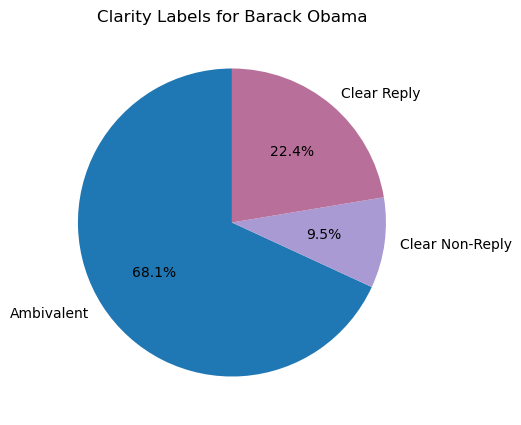

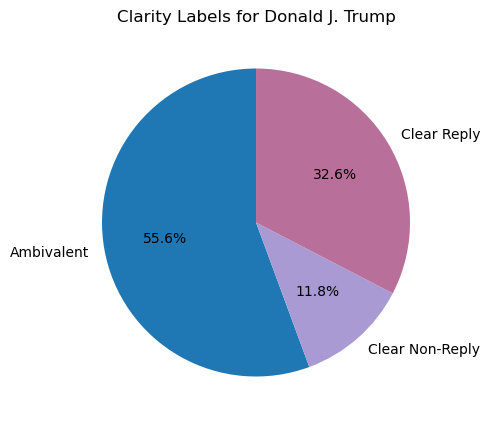

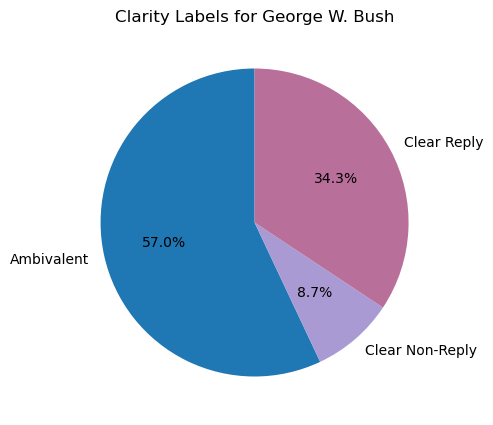

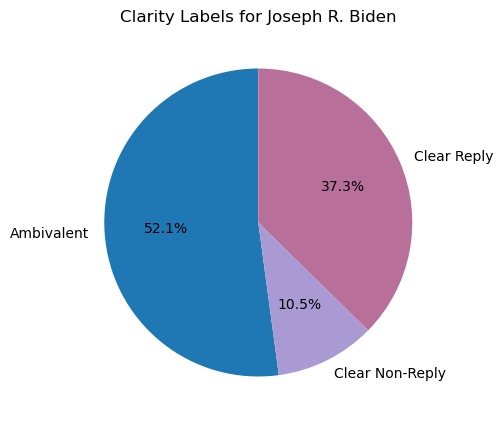

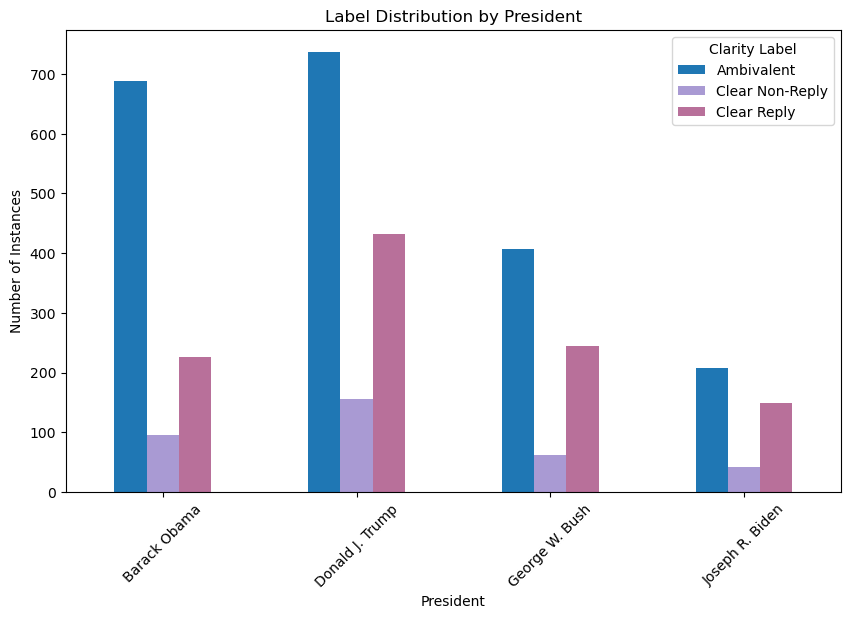

In [17]:
plot_clarity_distribution_by_president(df_train)

In [18]:
pd.crosstab(df_train["president"], df_train["clarity_label"], margins=True ,normalize="index")


clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
president,,,
Barack Obama,0.681188,0.095050,0.223762
Donald J. Trump,0.556226,0.117736,0.326038
George W. Bush,0.570028,0.086835,0.343137
Joseph R. Biden,0.521303,0.105263,0.373434
All,0.591647,0.103248,0.305104


#### Clarity Labels Distribution by Affirmative 
Affirmative questions are associated with a modest shift toward more decisive responses—both clear replies and clear non-replies—and a corresponding decrease in ambivalence. Specifically, when affirmative questions are present, the proportion of Ambivalent responses drops (from 60.5\% to 54.5\%), while both Clear Reply (from 29.9\% to 32.6\%) and Clear Non-Reply responses (from 9.6\% to 12.8\%) increase.

This pattern suggests that such questions may encourage the interviewee to respond more directly. However, the magnitude of these differences remains relatively small, indicating that while the effect is consistent, it is not particularly strong.

In [19]:
pd.crosstab(df_train["affirmative_questions"], df_train["clarity_label"], normalize="index")

clarity_label,Ambivalent,Clear Non-Reply,Clear Reply
affirmative_questions,,,
False,0.605007,0.096039,0.298954
True,0.545337,0.128238,0.326425


#### Clarity Labels Distribution by Year
The distribution of clarity labels across different years. As observed, there is no significant temporal variation in the distribution, as the relative proportions of the labels remain stable over time.

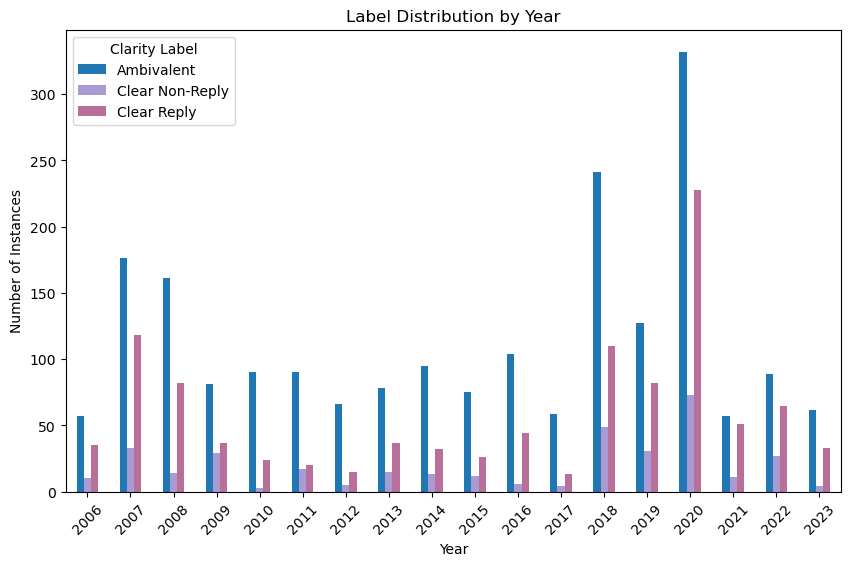

In [20]:


df_train["date"] = pd.to_datetime(df_train["date"])
df_train["year"] = df_train["date"].dt.year
label_by_president = df_train.groupby(["year","clarity_label"]).size().unstack()

colors = ["#1f77b4", "#a99ad3", "#b8709a"]
label_by_president.plot(
    kind="bar",
    stacked=False,
    figsize=(10,6),
    color=colors
)

plt.title("Label Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Number of Instances")
plt.legend(title="Clarity Label")
plt.xticks(rotation=45)

plt.show()

### Distribution of Questions per Year

The below heatmap presents the interview questions across presidents and years. The distribution of questions clearly aligns with the time periods of each presidency, with instances concentrated in the corresponding years. Additionally, some variation can be observed in the number of questions per year, as certain periods contain more instances than others. Overall, the visualization reflects the temporal structure of the dataset without any unexpected patterns.

## Textual Analysis

### Clarity Label Distribution by Word Count

 The dataset contains 3,448 responses, with an average length of approximately 294 words and a high standard deviation (301.54), indicating substantial variability in response length. The distribution is highly skewed, ranging from very short answers (1 word) to very long ones (up to 2,117 words). The median value (207 words) is lower than the mean, suggesting the presence of long outlier responses that increase the average.
 
 Examining the classes separately, Ambivalent responses not only constitute the majority of the dataset (2,040 samples) but also tend to be longer on average (331.86 words) and exhibit the highest variability (standard deviation of 319.53). Clear Reply responses include 1,052 samples with a moderate average length of 272.04 words and a relatively high spread (standard deviation of 269.54). In contrast, Clear Non-Reply responses form the smallest group (356 samples) and are considerably shorter, with an average length of 137.81 words and lower variability (standard deviation of 217.39).

Overall, these results indicate a clear relationship between response length and clarity. Shorter responses are more frequently associated with non-replies, while longer and more variable responses tend to correspond to ambivalent answers. This observation suggests that response length may serve as a useful feature for distinguishing between clarity categories.


=== Statistics by clarity_label ===
                 count        mean  median  min   max         std
clarity_label                                                    
Ambivalent        2040  331.857843   243.5    1  2117  319.526222
Clear Non-Reply    356  137.806180    39.5    1  1407  217.389827
Clear Reply       1052  272.041825   194.0    1  1592  269.540724


<Figure size 800x500 with 0 Axes>

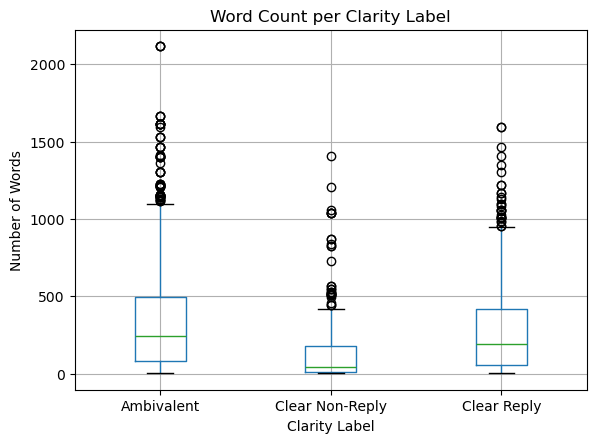

In [21]:
df_train = add_word_count(df_train, "interview_answer", "answer_word_count")
df_test = add_word_count(df_test, "interview_answer")
print_label_stats(df_train, "clarity_label", "answer_word_count")
plot_clarity_boxplot(df_train, "answer_word_count", "clarity_label")

Because the responses were labeled based on whether they addressed each sub-question, the same response may appear multiple times depending on the number of sub-questions. To preserve this information and capture the relationship between the label, the question, and the response, a unified text field was created by combining them into a single input.

Additionally, an extra feature was introduced representing the number of words in each response. This decision was motivated by the observation that response length is correlated with the distinction between clarity classes, and thus may provide useful information for improving classification performance.

In [22]:
train = df_train[["question", "interview_answer", "clarity_label","answer_word_count"]].copy()
train["text"] = ( train["question"] + " " + train["interview_answer"])

test = df_test[["question", "interview_answer", "clarity_label","answer_word_count"]].copy()
test ["text"] = ( test["question"] + " " + test["interview_answer"] ) 

#### Detection of text paterns in the data set
Only numbers were detected

In [20]:
detect_text_patterns(train["text"])


Starting dataset inspection...
----------------------------------------
Clean: No HTML Tags found.

Clean: No Emails found.

Clean: No URLs (http/www) found.

Clean: No Twitter Mentions (@) found.

Clean: No Hashtags (#) found.

Found: 1510 texts with Digits.
Clean: No Newlines (\n) found.

Clean: No Emojis found.

----------------------------------------
Inspection completed!


In [23]:
detect_text_patterns(test["text"])

Starting dataset inspection...
----------------------------------------
Clean: No HTML Tags found.

Clean: No Emails found.

Clean: No URLs (http/www) found.

Clean: No Twitter Mentions (@) found.

Clean: No Hashtags (#) found.

Found: 146 texts with Digits.
Clean: No Newlines (\n) found.

Clean: No Emojis found.

----------------------------------------
Inspection completed!


#### Detection of spelling errors
Spelling errors constitute a very small portion of the dataset (approximately 1.96\% of all words), suggesting that the textual data is generally clean and that spelling mistakes are unlikely to significantly affect the performance of the classification models.

In [24]:
check_spelling_errors(train["text"])
find_bad_samples(train["text"], threshold=30)

Total words: 1125356
Misspelled words: 22040
Percentage of misspelled words: 1.96%
Example misspelled words: ['thei', 'chineseno', 'aboutit', 've', 'donei']


In [25]:
check_spelling_errors(test["text"])
find_bad_samples(test["text"], threshold=30)

Total words: 110842
Misspelled words: 1591
Percentage of misspelled words: 1.44%
Example misspelled words: ['corke', 'nbc', 'll', 'hu', 'jintao']


In [26]:
train["clean_text"] = train["text"].apply(
    lambda x: clean_text(
        x,
        lowercase=True,     expand_contractions=True,

        remove_non_letters=True,
        remove_numbers=True,
        remove_stopwords=True,  remove_short_words= True ,min_word_length=2    
     )
)

check_spelling_errors(train["clean_text"])

Total words: 419719
Misspelled words: 12347
Percentage of misspelled words: 2.94%
Example misspelled words: ['thei', 'chineseno', 'aboutit', 'donei', 've']


In [27]:
test["clean_text"] = test["text"].apply(
    lambda x: clean_text(
        x,
        lowercase=True, expand_contractions=True,
        remove_non_letters=True,
        remove_numbers=True,
        remove_stopwords=True,  remove_short_words= True ,min_word_length=2          
    )
)

check_spelling_errors(test["clean_text"])

Total words: 42642
Misspelled words: 752
Percentage of misspelled words: 1.76%
Example misspelled words: ['corke', 'nbc', 'hu', 'jintao', 'roh']


### Detection of words or group of words that uniquely identify each class

 

In [28]:
show_top_ngrams_by_label(train, text_column="clean_text", label_column="clarity_label", n=1,top_n=15)
show_top_ngrams_by_label(train, text_column="clean_text", label_column="clarity_label", n=2,top_n=15)
show_top_ngrams_by_label(train, text_column="clean_text", label_column="clarity_label", n=3,top_n=15)




===== Label: Ambivalent =====
 1. going                          (4218)
 2. think                          (3946)
 3. people                         (3627)
 4. know                           (1976)
 5. president                      (1932)
 6. states                         (1565)
 7. like                           (1562)
 8. want                           (1555)
 9. united                         (1528)
10. said                           (1477)
11. country                        (1369)
12. way                            (1361)
13. time                           (1280)
14. lot                            (1271)
15. world                          (1229)

===== Label: Clear Non-Reply =====
 1. going                          (357)
 2. think                          (276)
 3. know                           (272)
 4. people                         (248)
 5. like                           (143)
 6. want                           (139)
 7. question                       (125)
 8. president   

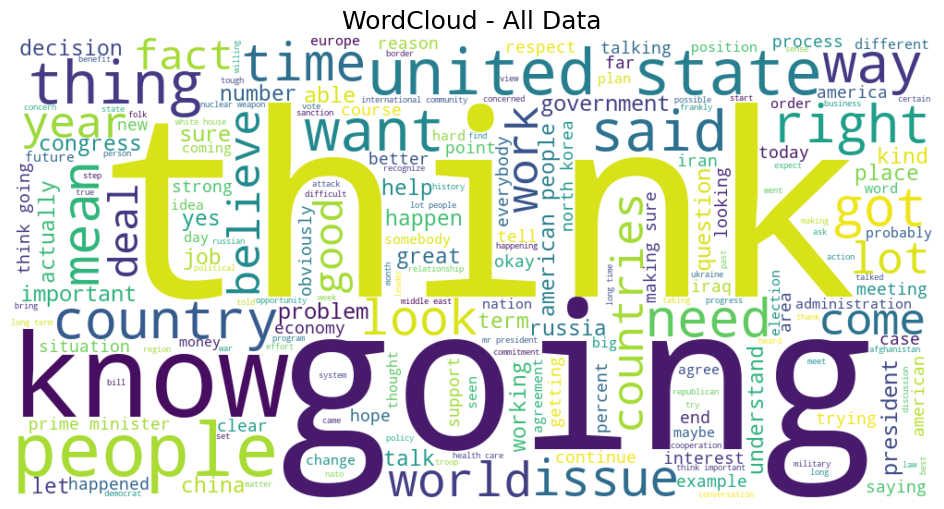

In [29]:
wordcloud_analysis(train)


# Experiments

## Tf-idf

### Load the dataset again
Because the responses were labeled based on whether they addressed each sub-question, the same response may appear multiple times depending on the number of sub-questions. To preserve this information and capture the relationship between the label, the question, and the response, a unified text field was created by combining them into a single input.

In [46]:
df_train = add_word_count(df_train, "interview_answer", "answer_word_count")
df_test = add_word_count(df_test, "interview_answer","answer_word_count")


training_data = df_train[["question", "interview_answer", "clarity_label","answer_word_count"]].copy()
training_data["text"] = ( training_data["question"] + " " + training_data["interview_answer"])

test_data = df_test[["question", "interview_answer", "clarity_label","answer_word_count"]].copy()
test_data ["text"] = ( test_data["question"] + " " + test_data["interview_answer"] ) 


### Deletion of duplicate rows

In [47]:


print("Before drop_duplicates:", df_train.shape)

# 3. Drop duplicates
df_train = df_train.drop_duplicates(subset=["question", "interview_answer", "clarity_label"])

# 4. Reset the index after dropping duplicates so SKFold works correctly!
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("After drop_duplicates:", df_train.shape)

Before drop_duplicates: (3402, 22)
After drop_duplicates: (3402, 22)


### Baseline

As a baseline configuration, a simple preprocessing pipeline was applied, including lowercasing, removal of non-letter characters, and removal of numbers. For text representation, the default TF-IDF vectorization settings were used.

The baseline model achieved an F1-macro score of **0.5240 ± 0.0111** and an F1-weighted score of **0.5804 ± 0.0109**.

The results show that the model performs better on the Ambivalent class, which is also the majority class in the dataset. In contrast, performance on Clear Non-Reply and Clear Reply is considerably lower, indicating greater difficulty in distinguishing these categories. This pattern is also reflected in the confusion matrix, where the **Ambivalent** class is classified more accurately, while the other two categories show higher levels of misclassification.

Moreover, a noticeable gap is observed in the learning curves, which may be an indication of overfitting. This suggests that, although the model learns the training data relatively well, its ability to generalize to unseen data remains limited.

--- Starting Experiment: Baseline Experiment For TF-IDF ---
1. Cleaning text...
2. Vectorization using TFIDFProcessor...
=== TF-IDF Summary ===
Vocabulary size: 13768
Feature Matrix Size (Samples x Features): (3402, 13768)

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV Score:
0.5240

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5785 ± 0.0120
Precision macro     : 0.5199 ± 0.0130
Precision weighted  : 0.5832 ± 0.0099
Recall macro        : 0.5294 ± 0.0114
Recall weighted     : 0.5785 ± 0.0120
F1 macro            : 0.5240 ± 0.0111
F1 weighted         : 0.5804 ± 0.0109

Classification Report
----------------------------------------------------------------------
                 precision    

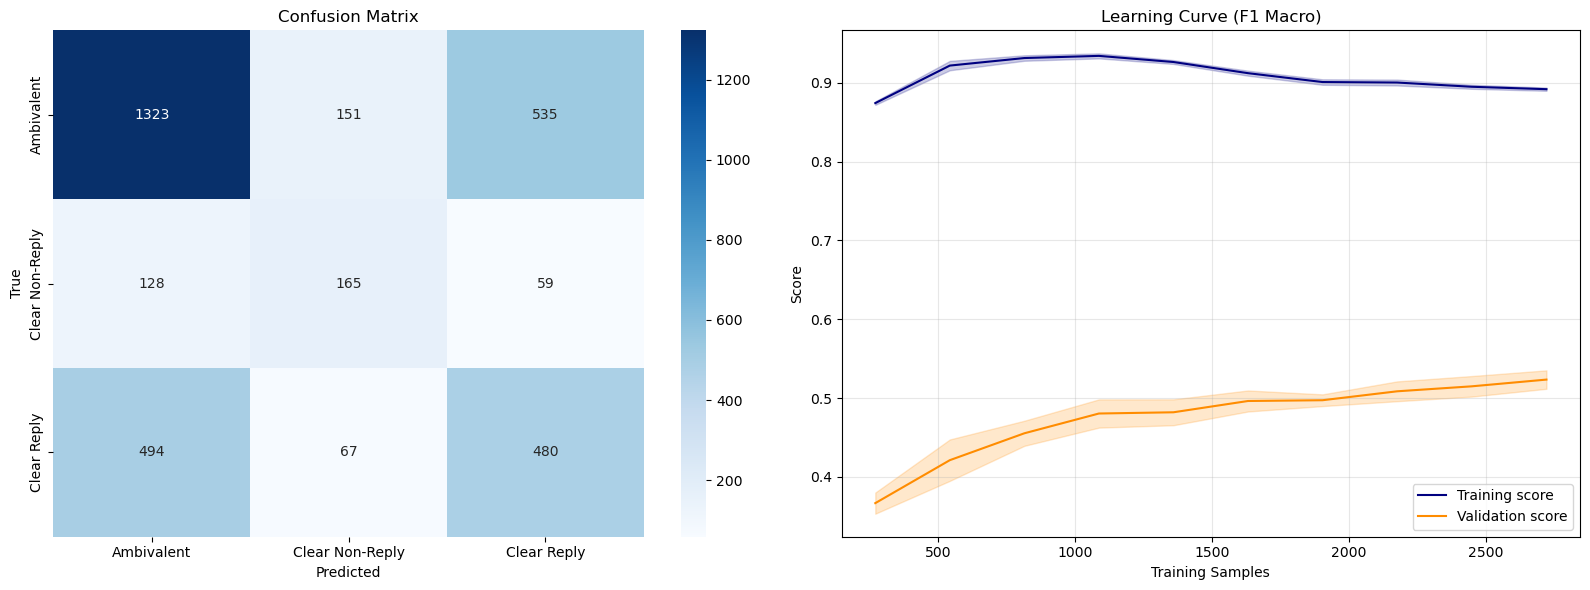

In [35]:
params_exp1 = {
    "lowercase": True,        
    "remove_non_letters": True,  
    "remove_numbers": True

    }

exp1 = ExperimentTracker(
    experiment_name="Baseline Experiment For TF-IDF",
    model_search_func=gridsearch_logistic,
    vectorizer=TFIDFProcessor(), 
    clean_func=clean_text
)

exp1.run_training(training_data, text_col="text", label_col="clarity_label", clean_params=params_exp1)
exp1.evaluator.plot_all()

### Stemming - Lemmatization

Both stemming and lemmatization produce results that are very close to the baseline, without yielding a clear overall improvement. In particular, stemming achieves an F1-macro score of **0.5174 ± 0.0201** and an F1-weighted score of **0.5789 ± 0.0138**, while lemmatization achieves an F1-macro score of **0.5215 ± 0.0216** and an F1-weighted score of **0.5852 ± 0.0158**. Although both methods slightly improve the macro-F1 score compared to the baseline, they lead to lower weighted-F1 scores. Overall, the differences are very small, suggesting that neither preprocessing technique provides a clear advantage.

In addition, the model continues to perform better on the Ambivalent class, which remains the dominant category, while the other two classes are more difficult to distinguish.


--- Starting Experiment: tf-idf-Stemming ---
1. Cleaning text...
2. Vectorization using TFIDFProcessor...
=== TF-IDF Summary ===
Vocabulary size: 8638
Feature Matrix Size (Samples x Features): (3402, 8638)

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\Margarita\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.5174

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5829 ± 0.0143
Precision macro     : 0.5232 ± 0.0211
Precision weighted  : 0.5763 ± 0.0139
Recall macro        : 0.5131 ± 0.0201
Recall weighted     : 0.5829 ± 0.0143
F1 macro            : 0.5174 ± 0.0201
F1 weighted         : 0.5789 ± 0.0138

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.67      0.70      0.68      2009
Clear Non-Reply       0.46      0.43      0.45       352
    Clear Reply       0.44      0.41      0.42      1041

       accuracy                           0.58      3402
      macro avg       0.52      0.51      0.52      3402
   weighted a

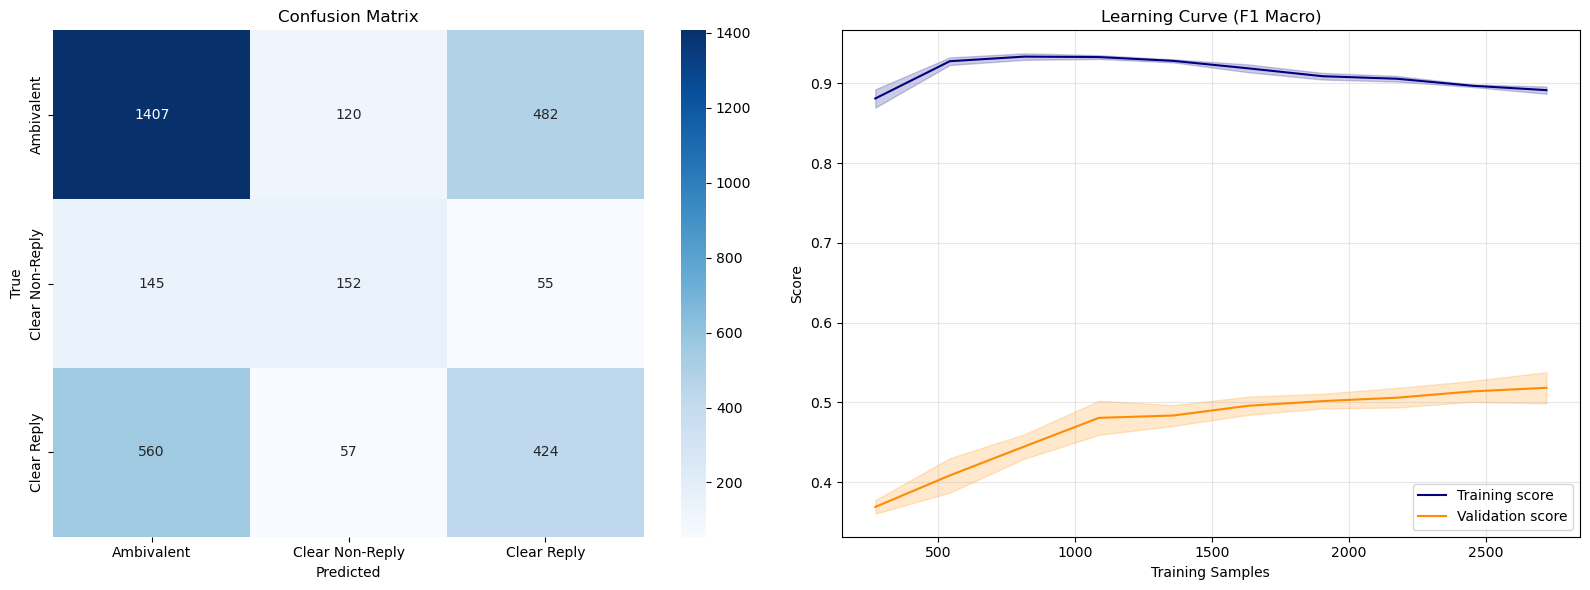

In [36]:

params_exp2_1 = {
    "lowercase": True,        
    "remove_non_letters": True,
    "remove_numbers": True,
    "stemming":True   
}

exp2_1 = ExperimentTracker(
    experiment_name="tf-idf-Stemming",
    model_search_func=gridsearch_logistic,
    vectorizer=TFIDFProcessor(), 
    clean_func=clean_text
)

exp2_1.run_training(training_data, text_col="text", label_col="clarity_label", clean_params=params_exp2_1)

exp2_1.evaluator.plot_all()

--- Starting Experiment: tf-idf-Lemmatize ---
1. Cleaning text...
2. Vectorization using TFIDFProcessor...
=== TF-IDF Summary ===
Vocabulary size: 10342
Feature Matrix Size (Samples x Features): (3402, 10342)

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\Margarita\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.5215

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5908 ± 0.0164
Precision macro     : 0.5296 ± 0.0256
Precision weighted  : 0.5821 ± 0.0157
Recall macro        : 0.5162 ± 0.0187
Recall weighted     : 0.5908 ± 0.0164
F1 macro            : 0.5215 ± 0.0216
F1 weighted         : 0.5852 ± 0.0158

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.67      0.72      0.69      2009
Clear Non-Reply       0.46      0.43      0.45       352
    Clear Reply       0.45      0.40      0.42      1041

       accuracy                           0.59      3402
      macro avg       0.53      0.52      0.52      3402
   weighted a

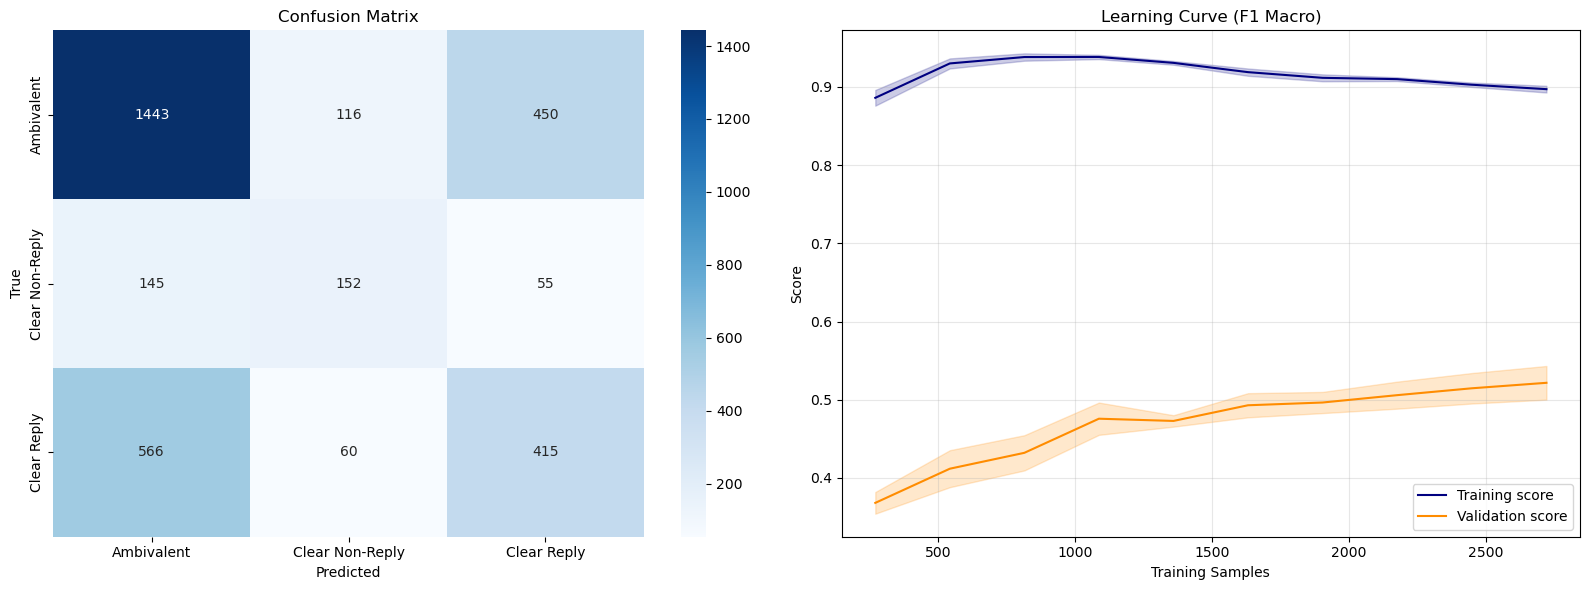

In [37]:

params_exp2_2 = {
    "lowercase": True,        
    "remove_non_letters": True,
    "remove_numbers": True,
    "lemmatize":True   
}

exp2_2 = ExperimentTracker(
    experiment_name="tf-idf-Lemmatize",
    model_search_func=gridsearch_logistic,
    vectorizer=TFIDFProcessor(), 
    clean_func=clean_text
)

exp2_2.run_training(training_data, text_col="text", label_col="clarity_label", clean_params=params_exp2_2)
exp2_2.evaluator.plot_all()

### Stop Words

Removing stop words produces mixed results, depending on the stop-word list used. The default stop-word removal setting achieves an F1-macro score of **0.5152 ± 0.0073** and an F1-weighted score of **0.5726 ± 0.0038**. Compared to the baseline, this configuration slightly improves macro-F1 but leads to a small decrease in weighted-F1. In contrast, the custom stop-word list achieves an F1-macro score of **0.5233 ± 0.0136** and an F1-weighted score of **0.5783 ± 0.0147**, outperforming both the baseline and the default stop-word configuration. These results suggest that the effectiveness of stop-word removal depends on the selected list, with the custom stop-word list providing the best overall performance. The improvement is relatively small for macro-F1 but more noticeable for weighted-F1.

--- Starting Experiment: Tf-idf-Stop_words ---
1. Cleaning text...
2. Vectorization using TFIDFProcessor...
=== TF-IDF Summary ===
Vocabulary size: 13483
Feature Matrix Size (Samples x Features): (3402, 13483)

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV Score:
0.5150

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5594 ± 0.0082
Precision macro     : 0.5013 ± 0.0072
Precision weighted  : 0.5765 ± 0.0045
Recall macro        : 0.5402 ± 0.0103
Recall weighted     : 0.5594 ± 0.0082
F1 macro            : 0.5150 ± 0.0076
F1 weighted         : 0.5651 ± 0.0071

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-sco

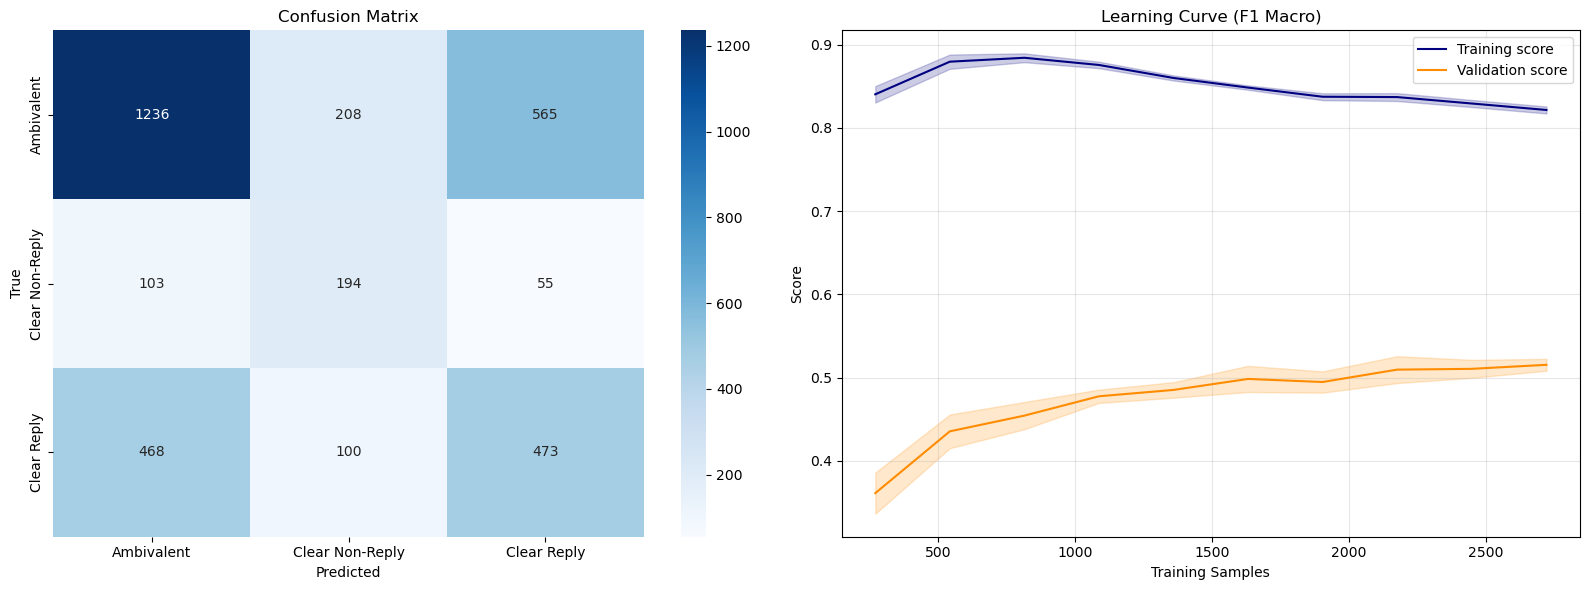

In [38]:
# Remove default stop words

params_exp3_1 = {
    "lowercase": True,        
    "remove_non_letters": True,
    "remove_numbers": True

}

exp3_1 = ExperimentTracker(
    experiment_name="Tf-idf-Stop_words",
    model_search_func=gridsearch_logistic,
    vectorizer=TFIDFProcessor(stop_words="english"), 
    clean_func=clean_text
)

exp3_1.run_training(training_data, text_col="text", label_col="clarity_label", clean_params=params_exp3_1)
exp3_1.evaluator.plot_all()


--- Starting Experiment: Baseline ---
1. Cleaning text...
2. Vectorization using TFIDFProcessor...
=== TF-IDF Summary ===
Vocabulary size: 13758
Feature Matrix Size (Samples x Features): (3402, 13758)

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV Score:
0.5232

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5752 ± 0.0141
Precision macro     : 0.5209 ± 0.0141
Precision weighted  : 0.5801 ± 0.0106
Recall macro        : 0.5271 ± 0.0123
Recall weighted     : 0.5752 ± 0.0141
F1 macro            : 0.5232 ± 0.0112
F1 weighted         : 0.5771 ± 0.0121

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   sup

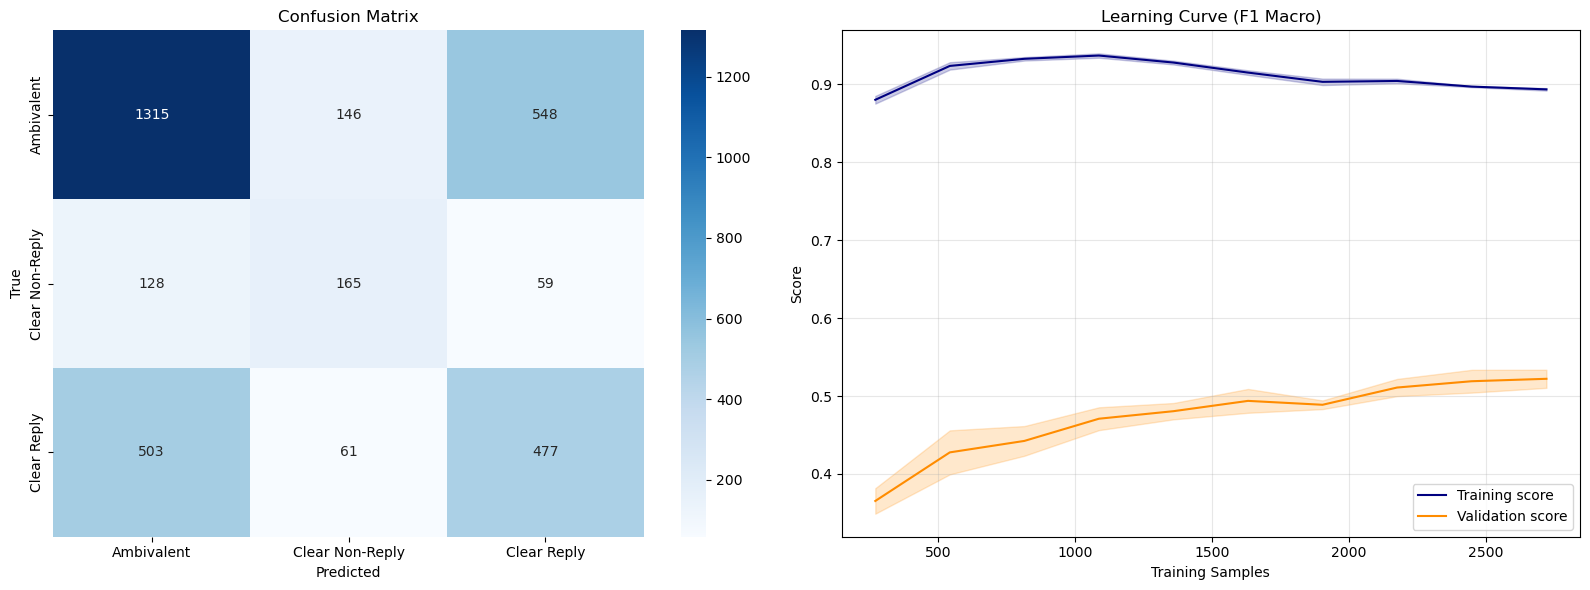

In [39]:
# Remove custom stop words
stop_words = [
    "in", "to", "and", "the",
    "a", "an", "of", "for", "on", "at", "are"
]

params_exp3_2 = {
    "lowercase": True,        
    "remove_non_letters": True,
    "remove_numbers": True,
    "remove_stopwords": True,       
    "custom_stopwords": stop_words 
}

exp3_2 = ExperimentTracker(
    experiment_name="Baseline",
    model_search_func=gridsearch_logistic,
    vectorizer=TFIDFProcessor(), 
    clean_func=clean_text
)

exp3_2.run_training(training_data, text_col="text", label_col="clarity_label", clean_params=params_exp3_2)
exp3_2.evaluator.plot_all()


### TF-IDF Parameters

After retaining the preprocessing steps that yielded the best performance results (lowercase, remove_non_letters, remove_numbers, normalize_spaces, remove_stopwords, custom_stopwords, stop_words, and lemmatize), the next step was to examine the parameters of the TF-IDF vectorizer. This analysis aimed to determine whether adjusting the vectorizer settings could further improve the classification performance.

#### Ngrams
Compared to the baseline, this experiment extends the TF-IDF representation to include unigrams, bigrams, aiming to capture richer contextual patterns.


Using the TF-IDF vectorizer with max_features = 20000 and ngram_range = (1, 2) led to a further improvement in performance. This configuration achieved an F1-macro score of **0.5337 ± 0.0219** and an F1-weighted score of **0.5888 ± 0.0167**, outperforming the previously tested configurations.

This suggests that adding bigrams helps the model capture useful contextual information that is not available when only single words are considered.

--- Starting Experiment: tf-idf-Max_features(20000)-ngram(1-2) ---
1. Cleaning text...
2. Vectorization using TFIDFProcessor...
=== TF-IDF Summary ===
Vocabulary size: 20000
Feature Matrix Size (Samples x Features): (3402, 20000)

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV Score:
0.5347

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5891 ± 0.0171
Precision macro     : 0.5401 ± 0.0148
Precision weighted  : 0.5881 ± 0.0152
Recall macro        : 0.5306 ± 0.0230
Recall weighted     : 0.5891 ± 0.0171
F1 macro            : 0.5347 ± 0.0191
F1 weighted         : 0.5882 ± 0.0162

Classification Report
----------------------------------------------------------------------
                 precis

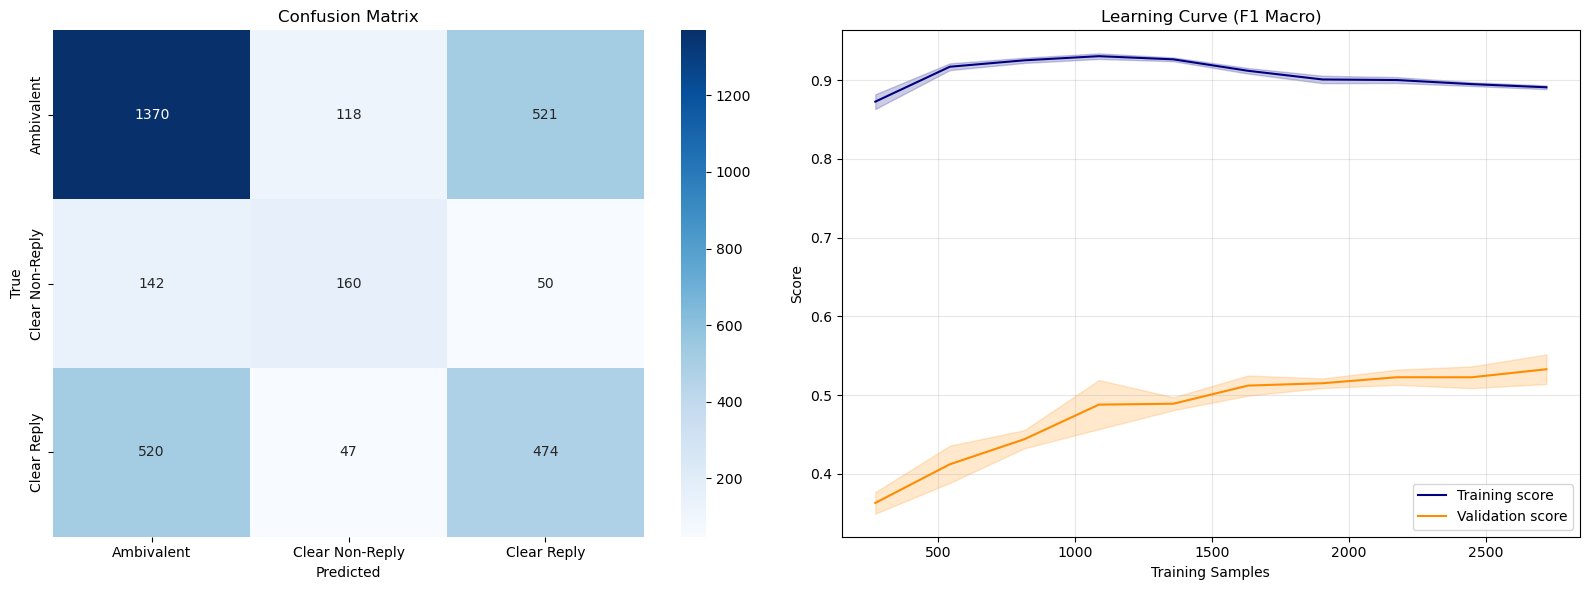

In [40]:
 # ngram_range=(1, 2) max features
stop_words = [
    "in", "to", "and", "the",
    "a", "an", "of", "for", "on", "at", "are"
]
params_exp4_1= {
    "lowercase": True,        
    "remove_non_letters": True,
    "remove_numbers": True,
    "normalize_spaces":True,"remove_stopwords": True,       
    "custom_stopwords": stop_words ,    "lemmatize":True   

}

exp4_1 = ExperimentTracker(
    experiment_name="tf-idf-Max_features(20000)-ngram(1-2)",
    model_search_func=gridsearch_logistic,
    vectorizer=TFIDFProcessor(  max_features=20000,     ngram_range=(1, 2)), 
    clean_func=clean_text
)

exp4_1.run_training(training_data, text_col="text", label_col="clarity_label", clean_params=params_exp4_1)

exp4_1.evaluator.plot_all()

In this experiment, the TF-IDF representation was extended to include unigrams, bigrams, and trigrams. However, this configuration produced slightly worse results than the previous one, achieving an F1-macro score of **0.5373 ± 0.0175** and an F1-weighted score of **0.5826 ± 0.0123**.




--- Starting Experiment: tf-idf-Max_features(20000)-ngram(1-3) ---
1. Cleaning text...
2. Vectorization using TFIDFProcessor...
=== TF-IDF Summary ===
Vocabulary size: 20000
Feature Matrix Size (Samples x Features): (3402, 20000)

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV Score:
0.5376

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5785 ± 0.0117
Precision macro     : 0.5235 ± 0.0159
Precision weighted  : 0.5921 ± 0.0132
Recall macro        : 0.5624 ± 0.0220
Recall weighted     : 0.5785 ± 0.0117
F1 macro            : 0.5376 ± 0.0180
F1 weighted         : 0.5827 ± 0.0120

Classification Report
----------------------------------------------------------------------
                 precisi

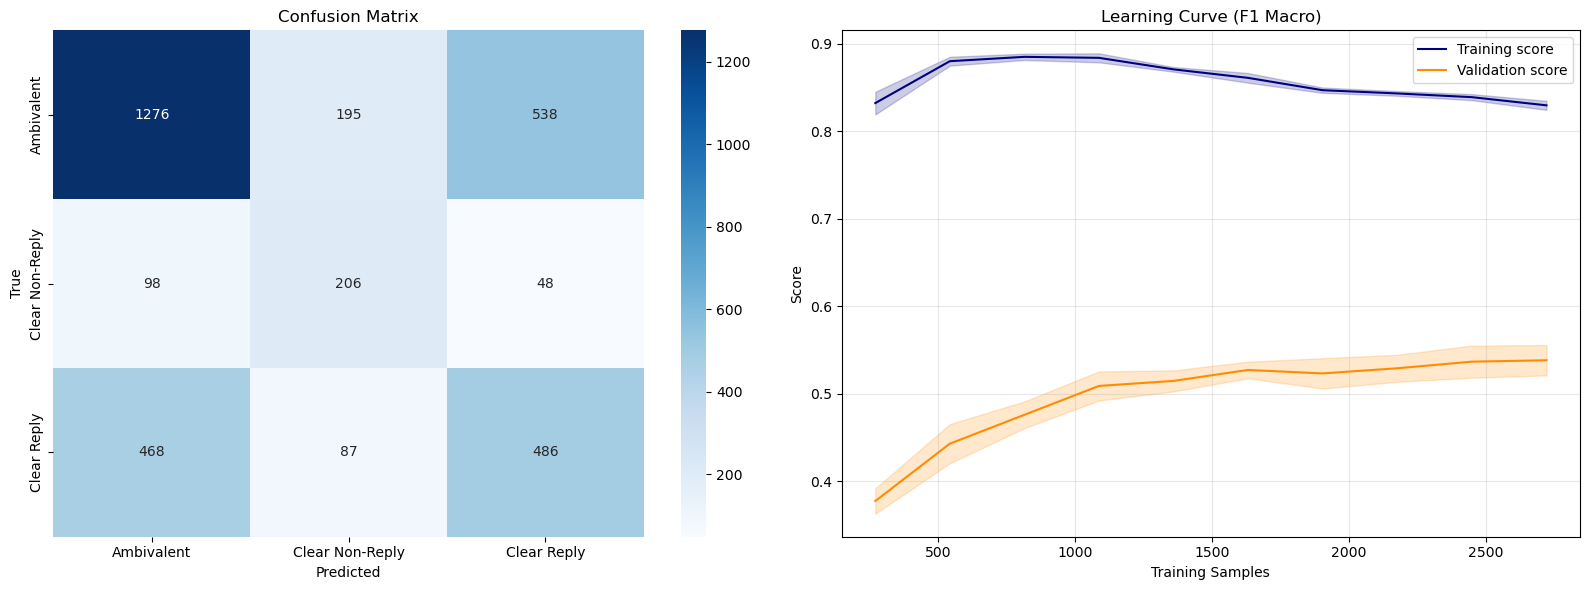

In [41]:
#  ngram_range=(1, 3)
params_exp4_2= {
    "lowercase": True,        
    "remove_non_letters": True,
    "remove_numbers": True,
    "normalize_spaces":True,"remove_stopwords": True,       
    "custom_stopwords": stop_words ,    "lemmatize":True   
        
}
exp4_2 = ExperimentTracker(
    experiment_name="tf-idf-Max_features(20000)-ngram(1-3)",
    model_search_func=gridsearch_logistic,
    vectorizer=TFIDFProcessor(  max_features=20000,     ngram_range=(1, 3)), 
    clean_func=clean_text
)

exp4_2.run_training(training_data, text_col="text", label_col="clarity_label", clean_params=params_exp4_2)
exp4_2.evaluator.plot_all()


In this experiment, additional TF-IDF parameters were introduced by setting min_df = 2, max_df = 0.9, and sublinear_tf = True, while keeping max_features = 20000 and ngram_range = (1, 2). This configuration achieved an F1-macro score of **0.5337 ± 0.0125** and an F1-weighted score of **0.5830 ± 0.0100**. These results are better than those obtained in the previous experiment, indicating that this parameter setting improves the quality of the TF-IDF representation.

--- Starting Experiment: tf-idf-Max_features(20000)-ngram(1-2)- mindif(2)-maxdf(0.9) ---
1. Cleaning text...
2. Vectorization using TFIDFProcessor...
=== TF-IDF Summary ===
Vocabulary size: 20000
Feature Matrix Size (Samples x Features): (3402, 20000)

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV Score:
0.5339

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5914 ± 0.0093
Precision macro     : 0.5396 ± 0.0083
Precision weighted  : 0.5892 ± 0.0073
Recall macro        : 0.5299 ± 0.0176
Recall weighted     : 0.5914 ± 0.0093
F1 macro            : 0.5339 ± 0.0129
F1 weighted         : 0.5898 ± 0.0081

Classification Report
----------------------------------------------------------------------
 

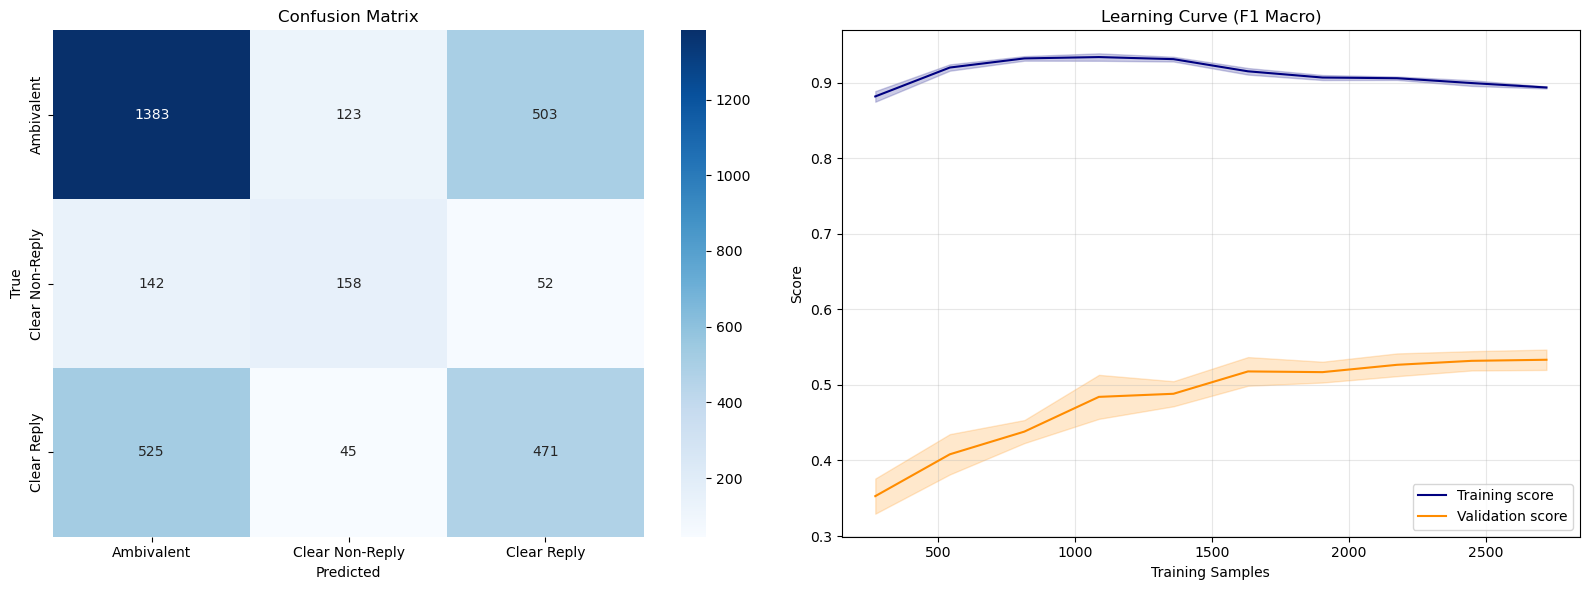

In [42]:
stop_words = [
    "in", "to", "and", "the",
    "a", "an", "of", "for", "on", "at", "are"
]
params_exp4_3= {
    "lowercase": True,        
    "remove_non_letters": True,
    "remove_numbers": True,
    "normalize_spaces":True,"remove_stopwords": True,       
    "custom_stopwords": stop_words,    "lemmatize":True   

}

exp4_3 = ExperimentTracker(
    experiment_name="tf-idf-Max_features(20000)-ngram(1-2)- mindif(2)-maxdf(0.9)",
    model_search_func=gridsearch_logistic,
    vectorizer=TFIDFProcessor(  max_features=20000,  
                                min_df=2,
                                max_df=0.9,
                                sublinear_tf=True,  
                                ngram_range=(1, 2)), 
    clean_func=clean_text
)

exp4_3.run_training(training_data, text_col="text", label_col="clarity_label", clean_params=params_exp4_3)

exp4_3.evaluator.plot_all()

#### Answer word count

Using the best-performing TF-IDF configuration, this experiment incorporates the answer_word_count feature into the Logistic Regression pipeline by combining the textual TF-IDF features with a scaled numerical feature through a ColumnTransformer.

This configuration achieved an F1-macro score of **0.5365 ± 0.0134** and an F1-weighted score of **0.5829 ± 0.0097**. Compared with the previous best TF-IDF model, the results are almost identical overall. The macro-F1 score shows a negligible improvement, whereas the weighted-F1 score is slightly lower.

These findings suggest that the answer_word_count feature provides only limited additional discriminative information beyond the textual TF-IDF features. In other words, incorporating answer length does not lead to a substantial improvement in class separability. In addition, the learning behavior remains similar, indicating that the overfitting observed in the TF-IDF experiments is still present.

 

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV Score:
0.5337

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5758 ± 0.0074
Precision macro     : 0.5194 ± 0.0113
Precision weighted  : 0.5896 ± 0.0096
Recall macro        : 0.5592 ± 0.0140
Recall weighted     : 0.5758 ± 0.0074
F1 macro            : 0.5337 ± 0.0125
F1 weighted         : 0.5802 ± 0.0078

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.69      0.63      0.66      2009
Clear Non-Reply       0.41      0.58      0.48       352
    Clear Reply       0.45      0.46      0.46      1041

       accuracy                           0.58      3402
      macro avg       0.52      0.56      0.53  

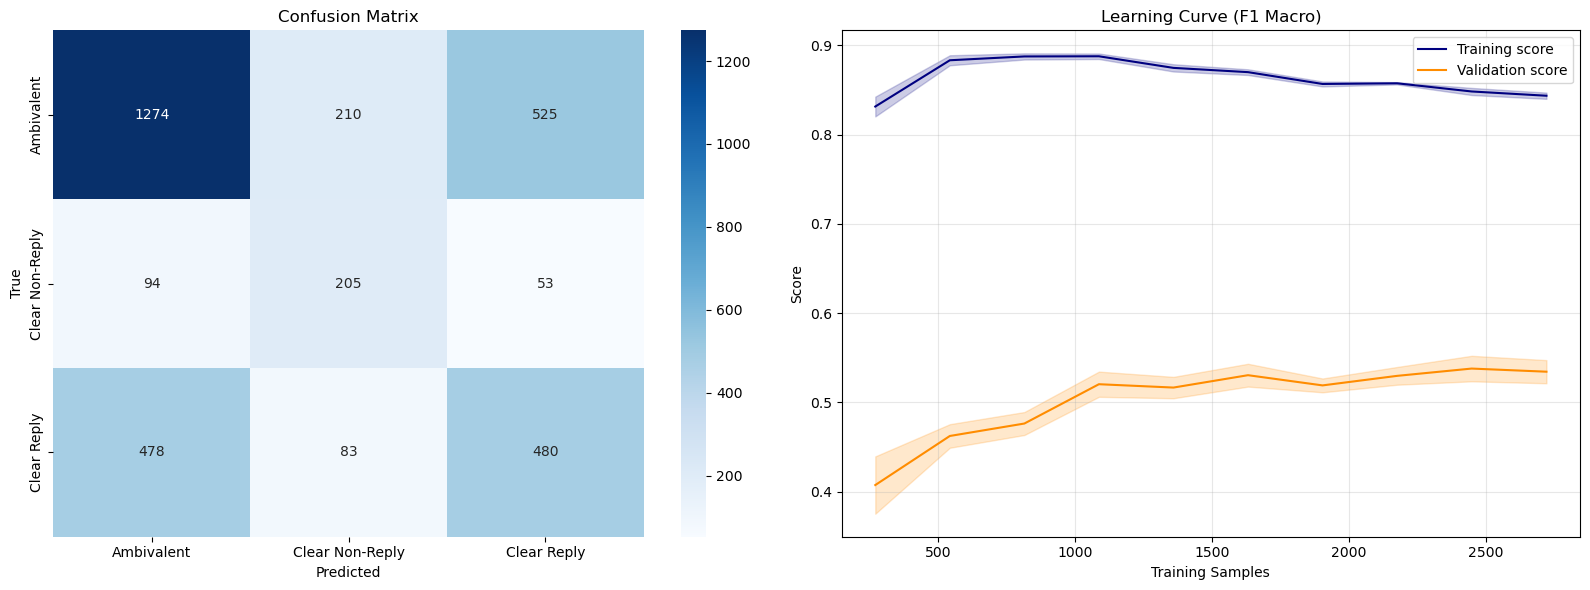

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

stop_words = [
    "in", "to", "and", "the",
    "a", "an", "of", "for", "on", "at", "are"
]

X_train = training_data[['text', 'answer_word_count']].copy()
y_train = training_data['clarity_label']

X_test = test_data[['text', 'answer_word_count']].copy()
y_test = test_data['clarity_label']

X_train['text'] = X_train['text'].apply(
    lambda x: clean_text(x, lowercase=True, remove_non_letters=True, remove_numbers=True, normalize_spaces=True, lemmatize=True,    remove_stopwords=True, custom_stopwords=stop_words)
)
X_test['text'] = X_test['text'].apply(
    lambda x: clean_text(x, lowercase=True, remove_non_letters=True, remove_numbers=True, normalize_spaces=True, lemmatize=True, remove_stopwords=True, custom_stopwords=stop_words)
)


preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=20000,  
                                min_df=2,
                                max_df=0.9,
                                sublinear_tf=True,  
                                ngram_range=(1, 2)), 'text'), 
        ('scaler', StandardScaler(), ['answer_word_count'])
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

best_model = gridsearch_logistic(X_train_transformed, y_train)


final_evaluator = ModelEvaluator(model=best_model, cv_folds=5)
final_evaluator.run_evaluation(X_train_transformed, y_train)
final_evaluator.plot_all()



Conclusion

Overall, the results show that the TF-IDF and Logistic Regression approach gives acceptable performance, but it has clear limitations for this classification task. Some preprocessing steps and TF-IDF parameter changes improved the scores slightly, but none of the experiments changed the general behavior of the model in an important way.

In most experiments, the confusion matrices look very similar. The model usually performs better on the Ambivalent class, which is also the majority class, while Clear Non-Reply and Clear Reply are classified less accurately. This means that the model finds it easier to recognize the dominant class and has more difficulty separating the other two classes.

The learning curves also show a similar pattern in all TF-IDF experiments. There is a clear gap between training and validation performance, which suggests overfitting. In other words, the model learns the training data better than it generalizes to new unseen examples. Since this pattern appears in all experiments, overfitting seems to be a general weakness of this TF-IDF-based method.

Among the tested settings, the best results were achieved by tuning the TF-IDF parameters, especially with unigrams and bigrams and with additional settings such as min_df, max_df, and sublinear_tf. On the other hand,the answer_word_count feature did not lead to meaningful improvements.

In conclusion, TF-IDF with Logistic Regression is a simple and useful method, but it is not enough to fully separate the three classes in this task. 

## Word2Vec

### Load dataset again

Each sample was represented in the form ``Question: [question] Answer: [interview_answer]''. This representation was used in all Word2Vec-based experiments, as it was expected to provide additional contextual information and improve the representation of each instance.

In [48]:
df_train = add_word_count(df_train, "interview_answer", "answer_word_count")
df_test = add_word_count(df_test, "interview_answer","answer_word_count")

training_data = df_train[["question", "interview_answer", "clarity_label","answer_word_count"]].copy()
training_data["text"] = ("Question:"+ " " + training_data["question"] + "Answer:" +" " + training_data["interview_answer"])
test_data = df_test[["question", "interview_answer", "clarity_label","answer_word_count"]].copy()
test_data ["text"] = ( "Question:"+ " " + test_data["question"] + "Answer:" + " " + test_data["interview_answer"] ) 



In [49]:


print("Before drop_duplicates:", df_train.shape)

# 3. Drop duplicates
df_train = df_train.drop_duplicates(subset=["question", "interview_answer", "clarity_label"])

# 4. Reset the index after dropping duplicates so SKFold works correctly!
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("After drop_duplicates:", df_train.shape)

Before drop_duplicates: (3402, 22)
After drop_duplicates: (3402, 22)


### Baseline

#### Custom-trained Model

As a baseline for the Word2Vec representation, only a simple lowercasing step was applied during preprocessing. The model achieved an F1-macro score **0.4828 ± 0.0121** and an F1-weighted score of **0.5551 ± 0.0072**.

Compared with the TF-IDF baseline, this configuration performs slightly worse in terms of macro-F1, while its weighted-F1 score remains relatively close. However, an important difference can be observed in the learning curve. In this case, the gap between the training and validation scores gradually becomes smaller as the number of training samples increases. This suggests that the model does not exhibit the same clear overfitting behavior observed in the TF-IDF experiments. Instead, both curves remain relatively low and closer to each other, indicating more stable generalization.

At the same time, the confusion matrix follows a pattern similar to that observed in the TF-IDF experiments. The model still performs better on the Ambivalent class, while Clear Non-Reply and Clear Reply remain more difficult to classify correctly. This suggests that, although the Word2Vec-based representation may reduce overfitting, it does not substantially improve the model’s ability to distinguish between the three classes.

--- Starting Experiment: Baseline for w2v ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\Margarita\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.4897

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.6064 ± 0.0093
Precision macro     : 0.5306 ± 0.0131
Precision weighted  : 0.5824 ± 0.0147
Recall macro        : 0.4997 ± 0.0229
Recall weighted     : 0.6064 ± 0.0093
F1 macro            : 0.4897 ± 0.0187
F1 weighted         : 0.5680 ± 0.0115

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.84      0.73      2009
Clear Non-Reply       0.44      0.45      0.44       352
    Clear Reply       0.50      0.21      0.30      1041

       accuracy                           0.61      3402
      macro avg       0.53      0.50      0.49      3402
   weighted av

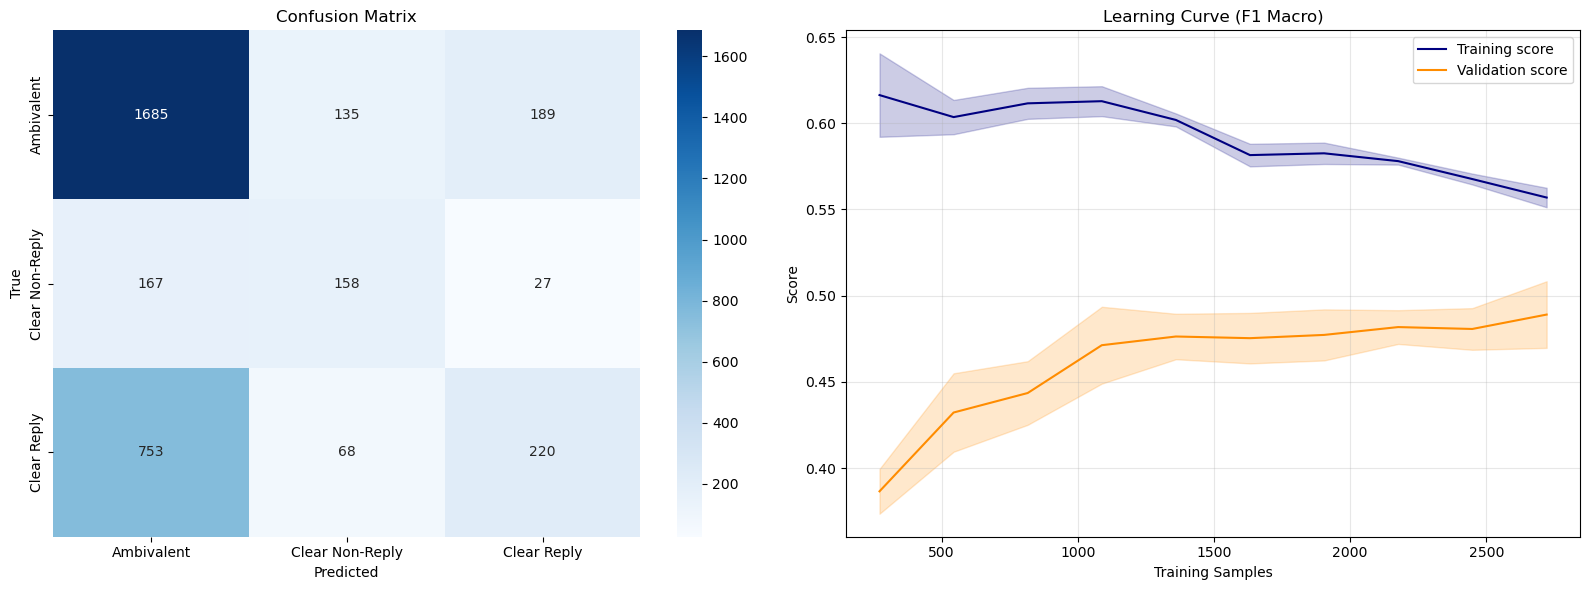

In [50]:
# Baseline train on the data 
exp1_1_w2v_params = {
            "lowercase": True     
}

exp1_1_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=300,      
    window=2,             
    epochs=20,           
    pooling="mean"
)

# 3. Setup Experiment Tracker
exp1_1_w2v = ExperimentTracker(
    experiment_name="Baseline for w2v",
    model_search_func=gridsearch_logistic,
    vectorizer=exp1_1_w2v_vectorizer,
    clean_func=clean_text
)

# 4. Run Training
exp1_1_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp1_1_w2v_params
)

# 5. Plot Evaluation 
exp1_1_w2v.evaluator.plot_all()



#### Pretrained Word2Vec (Google News)
### Pretrained Word2Vec

A second  experiment was conducted using pretrained Word2Vec embeddings from the Google News model, while again applying only lowercasing during preprocessing. This configuration achieved an **F1-macro score of 0.4677 ± 0.0113** and an **F1-weighted score of 0.5282 ± 0.0155**.

These results are worse than those of the Word2Vec model trained on the dataset itself, especially in terms of F1-macro. This suggests that the pretrained embeddings do not match the specific characteristics of the dataset as effectively as the domain-specific embeddings learned directly from the training data.

Therefore, although pretrained Word2Vec provides a ready-made semantic representation, in this case it does not improve performance and appears less suitable for the clarity classification task.

In [51]:

# Pretrained Word2Vec (Google News)

import kagglehub
from gensim.models import KeyedVectors
import os
dataset_path = kagglehub.dataset_download("spyrosbenekis/word2vec-google-news-300")
model_path = os.path.join(dataset_path, "word2vec_model", "word2vec-google-news-300.kv")



exp1_2_w2v_params= {
    "lowercase": True

}

google_w2v = KeyedVectors.load(model_path)
exp1_2_pretrained_w2v_vectorizer = PretrainedWord2VecAnalyzer(
    model=google_w2v, 
    pooling="mean",
    text_column="text"

)

exp1_2_pretrained = ExperimentTracker(
    experiment_name="GoogleNews_W2V_Baseline",
    model_search_func=gridsearch_logistic,
    vectorizer=exp1_2_pretrained_w2v_vectorizer,
    clean_func=clean_text
)

exp1_2_pretrained.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp1_2_w2v_params
)

exp1_2_pretrained.evaluator.plot_all()




ModuleNotFoundError: No module named 'kagglehub'

### Stopwords

In the Word2Vec experiments, removing stop words did not improve performance. Both the default and the custom stop-word settings produced results that were worse than or very close to the baseline Word2Vec model. More specifically, the custom stop-word setting achieved an F1-macro score of **0.4867 ± 0.0217** and an F1-weighted score of **0.5649 ± 0.0132**, while the default stop-word setting achieved an F1-macro score of **0.4699 ± 0.0168** and an F1-weighted score of **0.5508 ± 0.0119**.

These results suggest that stop words may still carry useful information in the Word2Vec representation, since the model relies on the full word context to learn meaningful embeddings. As a result, removing these words may reduce important contextual information and slightly weaken model performance.

--- Starting Experiment:  Custom Stop words W2V ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.4867

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5991 ± 0.0119
Precision macro     : 0.5159 ± 0.0215
Precision weighted  : 0.5721 ± 0.0106
Recall macro        : 0.4969 ± 0.0224
Recall weighted     : 0.5991 ± 0.0119
F1 macro            : 0.4867 ± 0.0217
F1 weighted         : 0.5649 ± 0.0132

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.82      0.73      2009
Clear Non-Reply       0.42      0.45      0.44       352
    Clear Reply       0.47      0.22      0.30      1041

       accuracy                           0.60      3402
      macro avg       0.52      0.50      0.49      3402
   weighted av

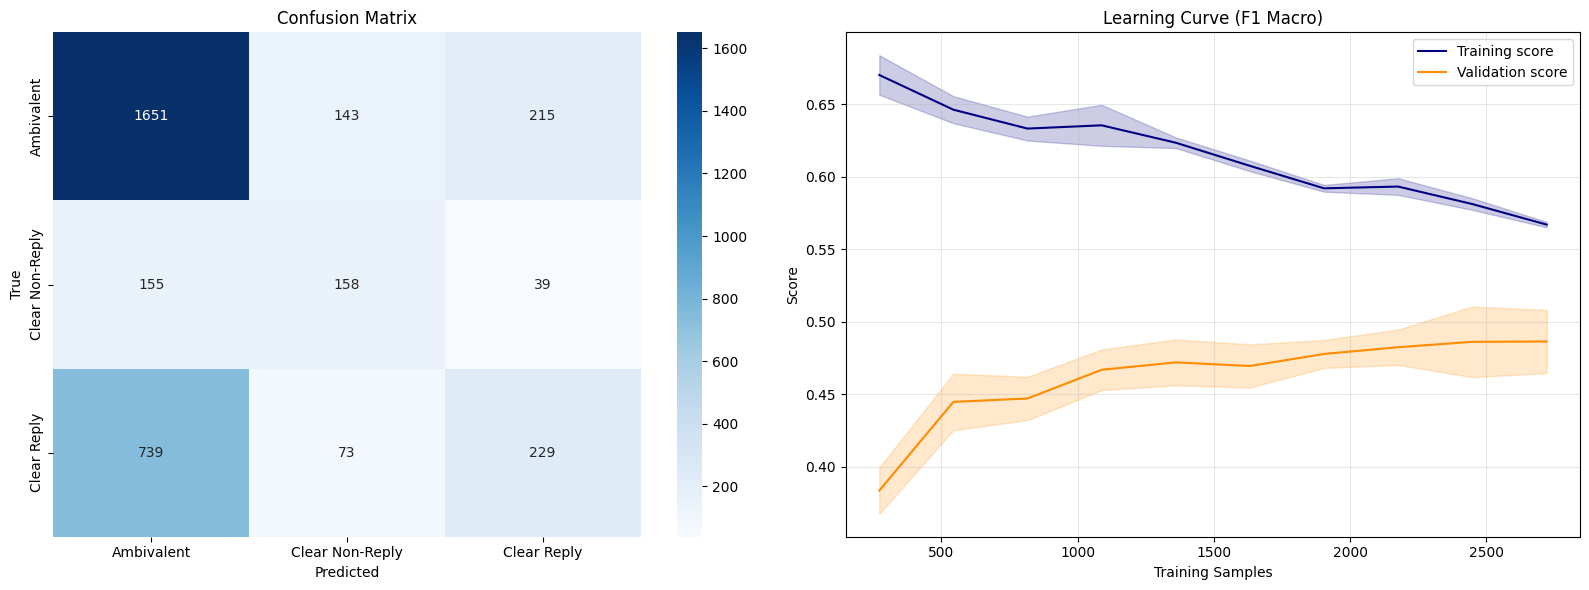

In [ ]:
# custom Stopwords
stop_words = [
    "in", "to", "and", "the",
    "a", "an", "of", "for", "on", "at", "are","ha","wa"
]
exp2_1_w2v_params= {
    "lowercase": True,  
    "remove_stopwords": True,       
    "custom_stopwords": stop_words}


exp2_1_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=300,      
    window=2,             
    epochs=20,           
    pooling="mean"
)

exp2_1_w2v = ExperimentTracker(
    experiment_name=" Custom Stop words W2V",
    model_search_func=gridsearch_logistic,
    vectorizer=exp2_1_w2v_vectorizer,
    clean_func=clean_text
)

exp2_1_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp2_1_w2v_params
)

exp2_1_w2v.evaluator.plot_all()


--- Starting Experiment:  Default stopwords ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.4699

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5794 ± 0.0117
Precision macro     : 0.4826 ± 0.0143
Precision weighted  : 0.5516 ± 0.0102
Recall macro        : 0.4867 ± 0.0165
Recall weighted     : 0.5794 ± 0.0117
F1 macro            : 0.4699 ± 0.0168
F1 weighted         : 0.5508 ± 0.0119

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.79      0.71      2009
Clear Non-Reply       0.38      0.45      0.41       352
    Clear Reply       0.42      0.22      0.29      1041

       accuracy                           0.58      3402
      macro avg       0.48      0.49      0.47      3402
   weighted av

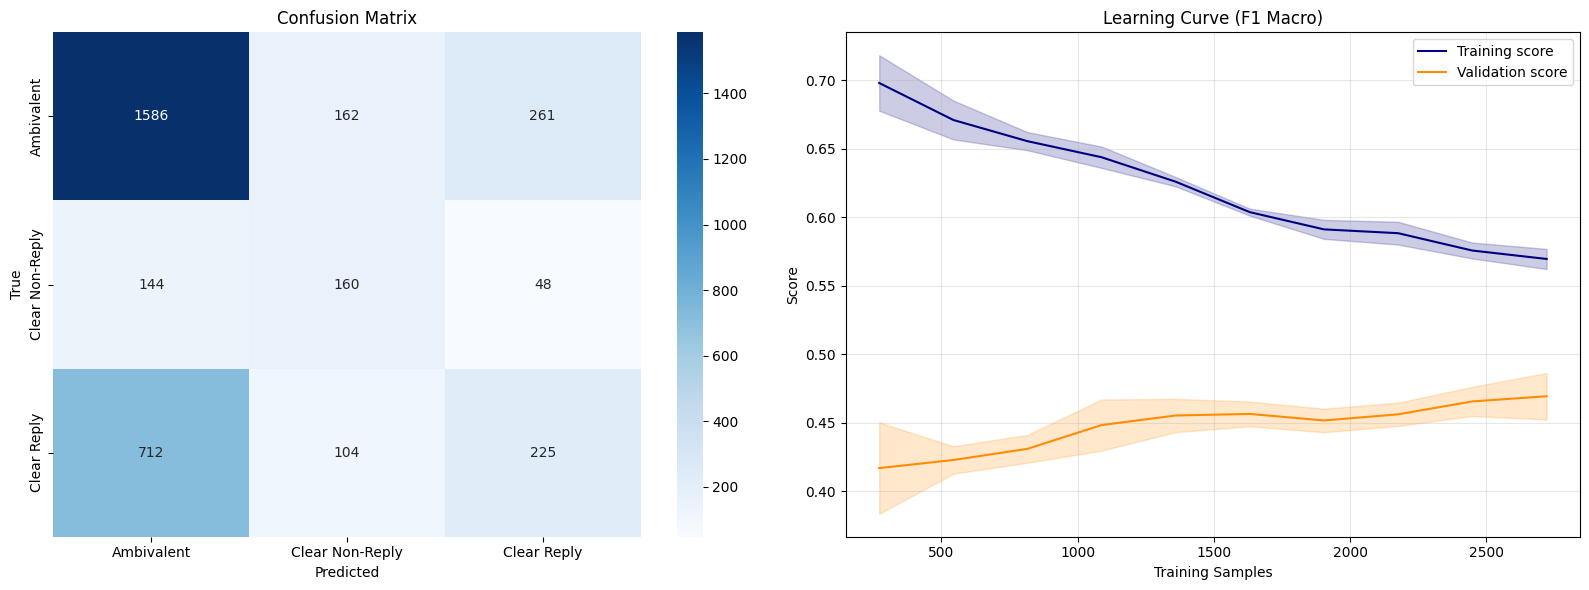

In [ ]:
# Default stopwords
exp2_2_w2v_params= {
    "lowercase": True,        
    "remove_non_letters": True,
    "remove_numbers": True,
    "normalize_spaces":True,
    "remove_stopwords": True      

}

exp2_2_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=300,      
    window=2,             
    epochs=20,           
    pooling="mean"
)

exp2_2_w2v = ExperimentTracker(
    experiment_name=" Default stopwords",
    model_search_func=gridsearch_logistic,
    vectorizer=exp2_2_w2v_vectorizer,
    clean_func=clean_text
)


exp2_2_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp2_2_w2v_params
)

exp2_2_w2v.evaluator.plot_all()




### Lemmatization

Applying lemmatization produced results that were very close to the Word2Vec baseline. This configuration achieved an F1-macro score of **0.4992 ± 0.0154** and an F1-weighted score of **0.5689 ± 0.0099**. Compared with the baseline, macro-F1 shows a slight increase, while weighted-F1 is slightly lower.

This suggests that lemmatization may help normalize different word forms into a common base form, which can improve consistency in the learned representations. However, the overall effect remains limited, as the results are very close to those of the baseline model. 

--- Starting Experiment: Lemmatize w2v ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.4992

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5894 ± 0.0136
Precision macro     : 0.5107 ± 0.0153
Precision weighted  : 0.5703 ± 0.0122
Recall macro        : 0.5097 ± 0.0207
Recall weighted     : 0.5894 ± 0.0136
F1 macro            : 0.4992 ± 0.0154
F1 weighted         : 0.5689 ± 0.0099

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.77      0.71      2009
Clear Non-Reply       0.42      0.48      0.45       352
    Clear Reply       0.46      0.28      0.34      1041

       accuracy                           0.59      3402
      macro avg       0.51      0.51      0.50      3402
   weighted a

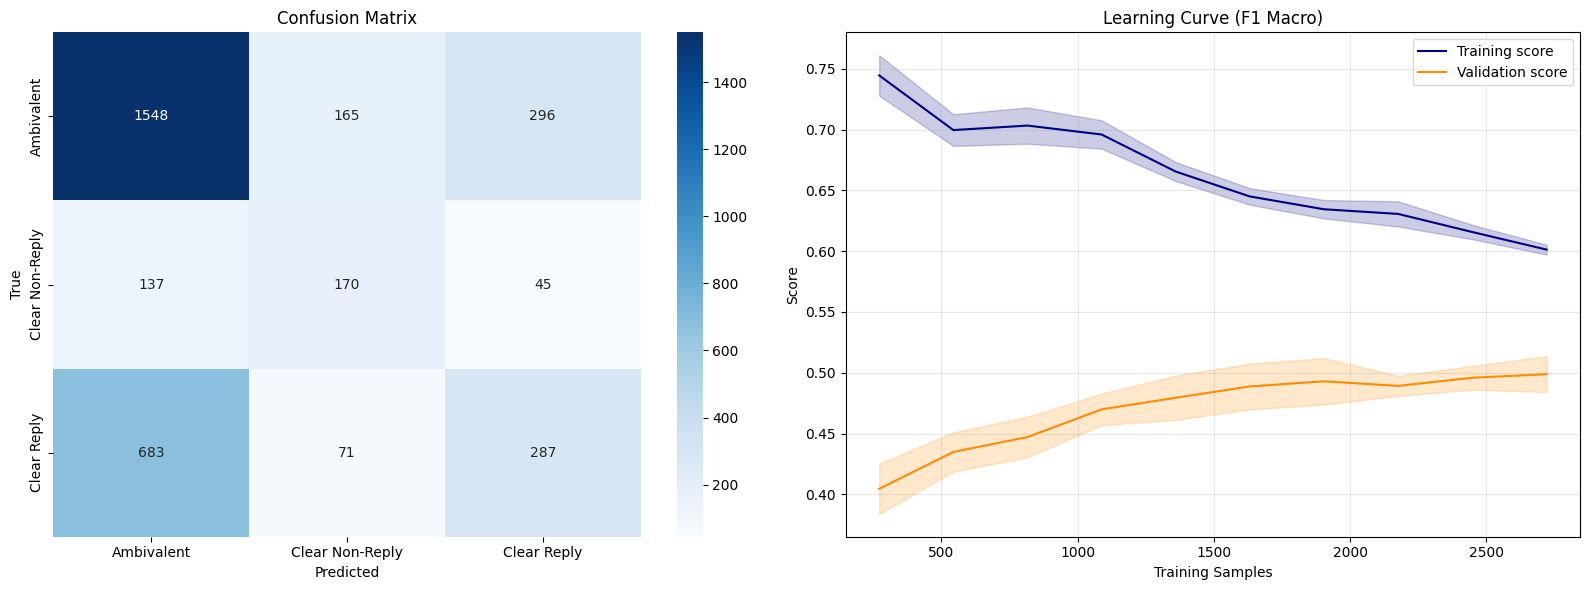

In [ ]:

exp3_w2v_params= {
    "lowercase": True,        
     "lemmatize":True   

}

exp3_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=300,     
    window=2,            
    epochs=20,           
    pooling="mean"
)

exp3_w2v = ExperimentTracker(
    experiment_name="Lemmatize w2v",
    model_search_func=gridsearch_logistic,
    vectorizer=exp3_w2v_vectorizer,
    clean_func=clean_text
)

exp3_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp3_w2v_params
)

exp3_w2v.evaluator.plot_all()




###  Experiments at w2v parameters

#### Vector Size
After retaining lemmatization, the vector size of the Word2Vec model was increased from 300 to 500 in order to examine whether a richer embedding space could improve performance. This configuration achieved an F1-macro score of ** 0.5021 ± 0.0103** and an F1-weighted score of **0.5695 ± 0.0074**.

The results are very similar to those of the previous lemmatized Word2Vec setting. While the weighted-F1 score shows a negligible increase, the macro-F1 score is slightly lower. This suggests that increasing the dimensionality of the embeddings provides little additional benefit for this task, while the overall behavior of the model remains unchanged.

--- Starting Experiment: Vector size 500 w2v ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.5021

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5876 ± 0.0097
Precision macro     : 0.5127 ± 0.0097
Precision weighted  : 0.5709 ± 0.0099
Recall macro        : 0.5110 ± 0.0146
Recall weighted     : 0.5876 ± 0.0097
F1 macro            : 0.5021 ± 0.0103
F1 weighted         : 0.5695 ± 0.0074

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.76      0.70      2009
Clear Non-Reply       0.42      0.48      0.45       352
    Clear Reply       0.46      0.29      0.36      1041

       accuracy                           0.59      3402
      macro avg       0.51      0.51      0.50      3402
   weighted a

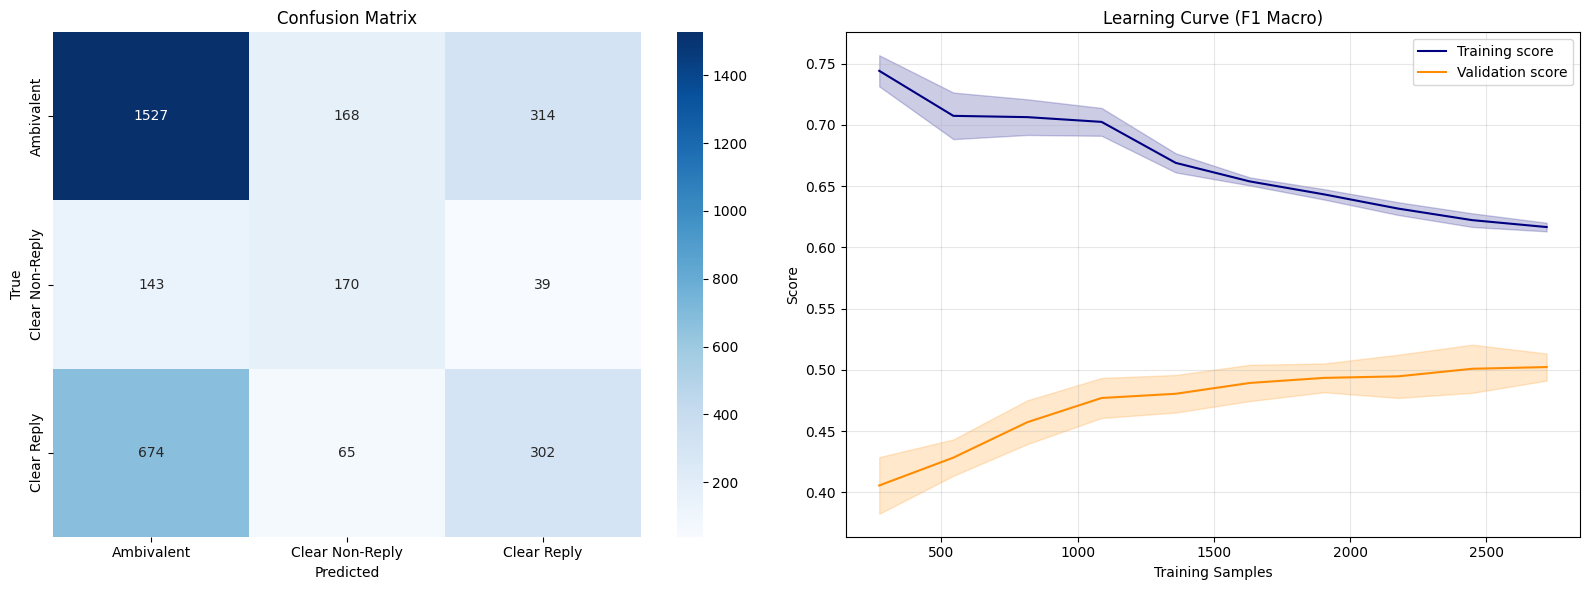

In [ ]:
# Vector size 500
exp4_1_w2v_params= {
    "lowercase": True,     "lemmatize":True      
}


exp4_1_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=500,      
    window=2,             
    epochs=20,           
    pooling="mean"
)

exp4_1_w2v = ExperimentTracker(
    experiment_name="Vector size 500 w2v",
    model_search_func=gridsearch_logistic,
    vectorizer=exp4_1_w2v_vectorizer,
    clean_func=clean_text
)


exp4_1_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp4_1_w2v_params
)

exp4_1_w2v.evaluator.plot_all()




#### Skip-Gram

The Skip-Gram variant of Word2Vec was tested by setting the parameter sg = 1, while keeping the rest of the parameters unchanged. This configuration achieved an F1-macro score of **0.4978 ± 0.0065** and an F1-weighted score of **0.5669 ± 0.0082**.

Compared with both the baseline Word2Vec model and the previous lemmatized configuration, this setting produced worse results. This suggests that using the Skip-Gram architecture does not improve performance for this task and, in this case, leads to lower classification scores.

--- Starting Experiment: sg=1 w2v ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.4978

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5876 ± 0.0092
Precision macro     : 0.5085 ± 0.0068
Precision weighted  : 0.5687 ± 0.0072
Recall macro        : 0.5104 ± 0.0102
Recall weighted     : 0.5876 ± 0.0092
F1 macro            : 0.4978 ± 0.0065
F1 weighted         : 0.5669 ± 0.0082

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.77      0.71      2009
Clear Non-Reply       0.42      0.49      0.45       352
    Clear Reply       0.45      0.27      0.34      1041

       accuracy                           0.59      3402
      macro avg       0.51      0.51      0.50      3402
   weighted a

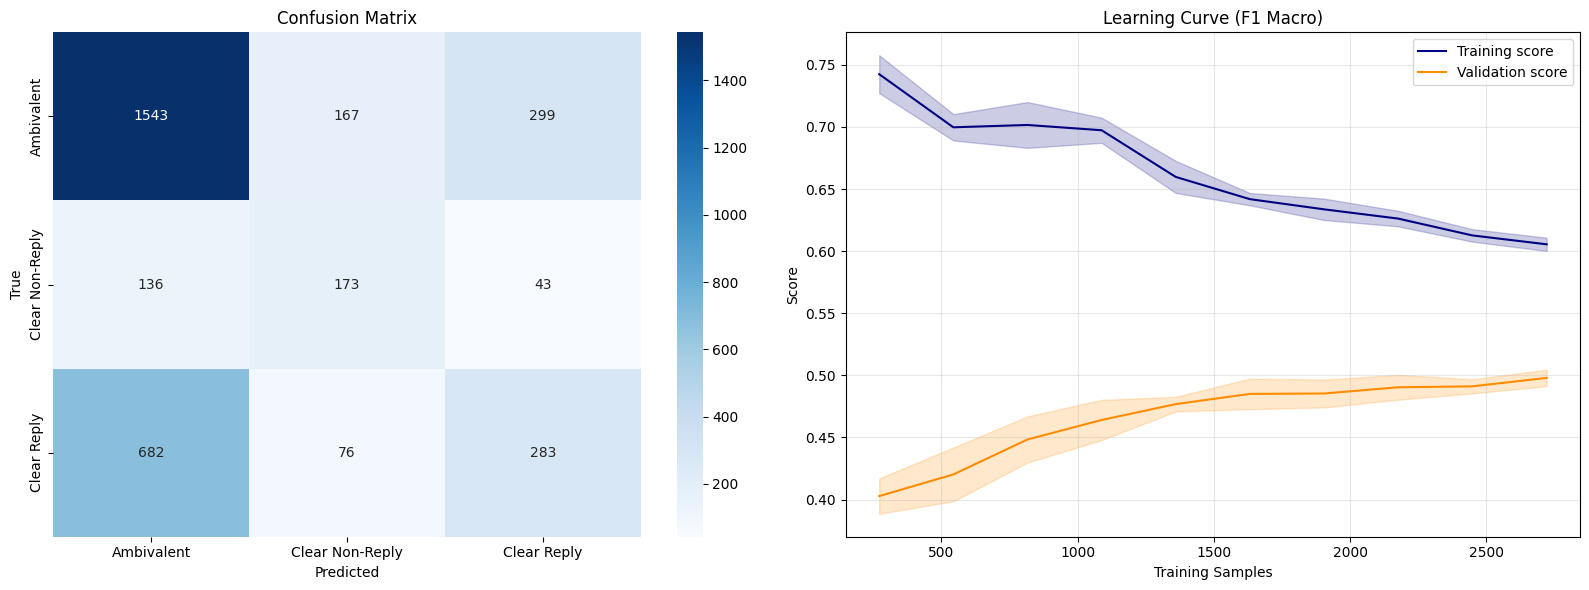

In [ ]:
# sg= 1 Skip gram algorithm
exp4_2_w2v_params= {
    "lowercase": True,     "lemmatize":True       
}

exp4_2_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=300,      
    window=2,             
    epochs=20,   
    sg=1,        
    pooling="mean"
)

exp4_2_w2v = ExperimentTracker(
    experiment_name="sg=1 w2v",
    model_search_func=gridsearch_logistic,
    vectorizer=exp4_2_w2v_vectorizer,
    clean_func=clean_text
)

exp4_2_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp4_2_w2v_params
)

exp4_2_w2v.evaluator.plot_all()



#### Experiments on Pooling Strategy
Different pooling strategies were also tested for the Word2Vec representations, including max pooling and tfidf_weighted_mean. However, neither configuration outperformed the best previous Word2Vec setup. More specifically, max pooling achieved an F1-macro score of **0.4705 ± 0.0253** and an F1-weighted score of **0.5509 ± 0.0198**, while tfidf_weighted_mean achieved an F1-macro score of **0.4767 ± 0.0155** and an F1-weighted score of **0.5519 ± 0.0045**.

These results suggest that changing the pooling strategy does not improve the quality of the document representation for this task

--- Starting Experiment: max w2v ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Best Parameters:
{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.4705

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5791 ± 0.0227
Precision macro     : 0.4909 ± 0.0291
Precision weighted  : 0.5609 ± 0.0220
Recall macro        : 0.4904 ± 0.0230
Recall weighted     : 0.5791 ± 0.0227
F1 macro            : 0.4705 ± 0.0253
F1 weighted         : 0.5509 ± 0.0198

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.64      0.78      0.71      2009
Clear Non-Reply       0.36      0.47      0.40       352
    Clear Reply       0.46      0.22      0.30      1041

       accuracy                           0.58      3402
      macro avg       0.49      0.49      0.47      3402
   weighted 

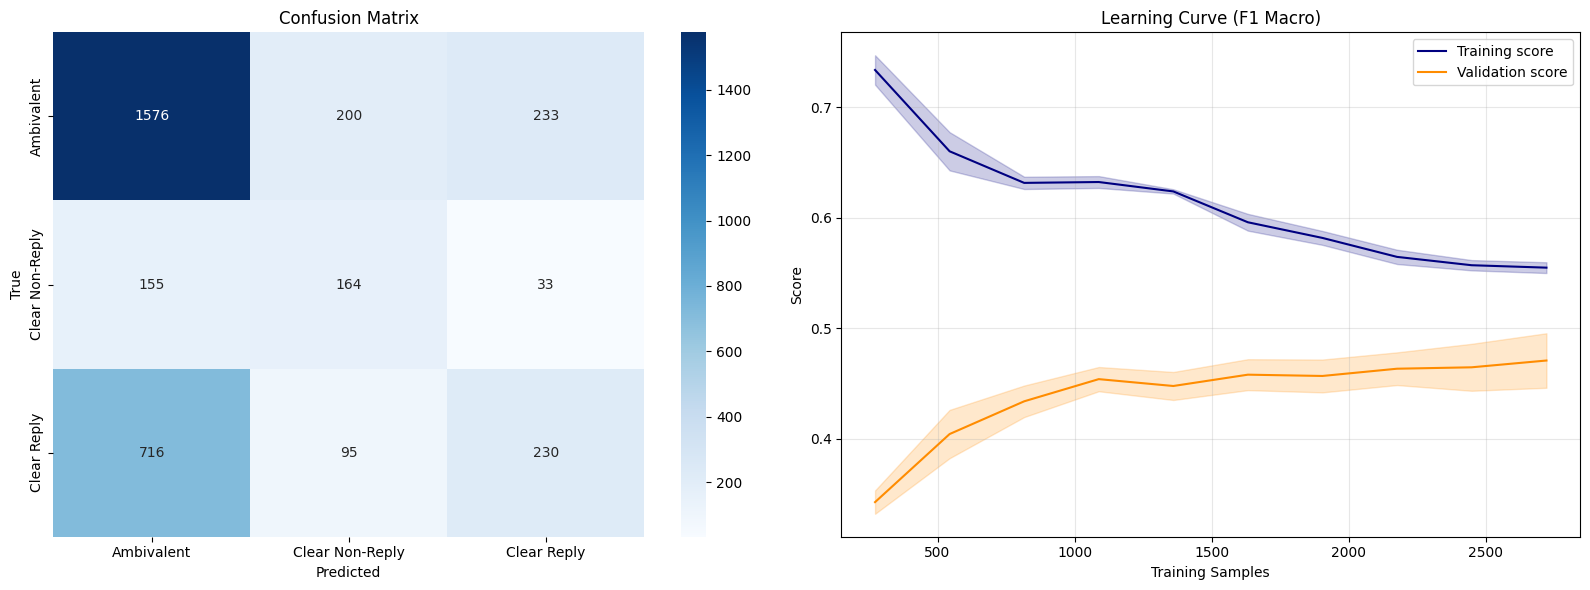

In [ ]:
# max
exp4_3_w2v_params= {
    "lowercase": True,     "lemmatize":True   

}

exp4_3_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=300,      
    window=2,             
    epochs=20,           
    pooling="max"
)

exp4_3_w2v = ExperimentTracker(
    experiment_name="max w2v",
    model_search_func=gridsearch_logistic,
    vectorizer=exp4_3_w2v_vectorizer,
    clean_func=clean_text
)

exp4_3_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp4_3_w2v_params
)

exp4_3_w2v.evaluator.plot_all()



--- Starting Experiment: tfidf_weighted_mean w2v ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.4767

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5700 ± 0.0033
Precision macro     : 0.4843 ± 0.0132
Precision weighted  : 0.5477 ± 0.0043
Recall macro        : 0.4823 ± 0.0170
Recall weighted     : 0.5700 ± 0.0033
F1 macro            : 0.4767 ± 0.0155
F1 weighted         : 0.5519 ± 0.0045

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.75      0.69      2009
Clear Non-Reply       0.40      0.43      0.41       352
    Clear Reply       0.41      0.27      0.33      1041

       accuracy                           0.57      3402
      macro avg       0.48      0.48      0.48      3402
   weighted a

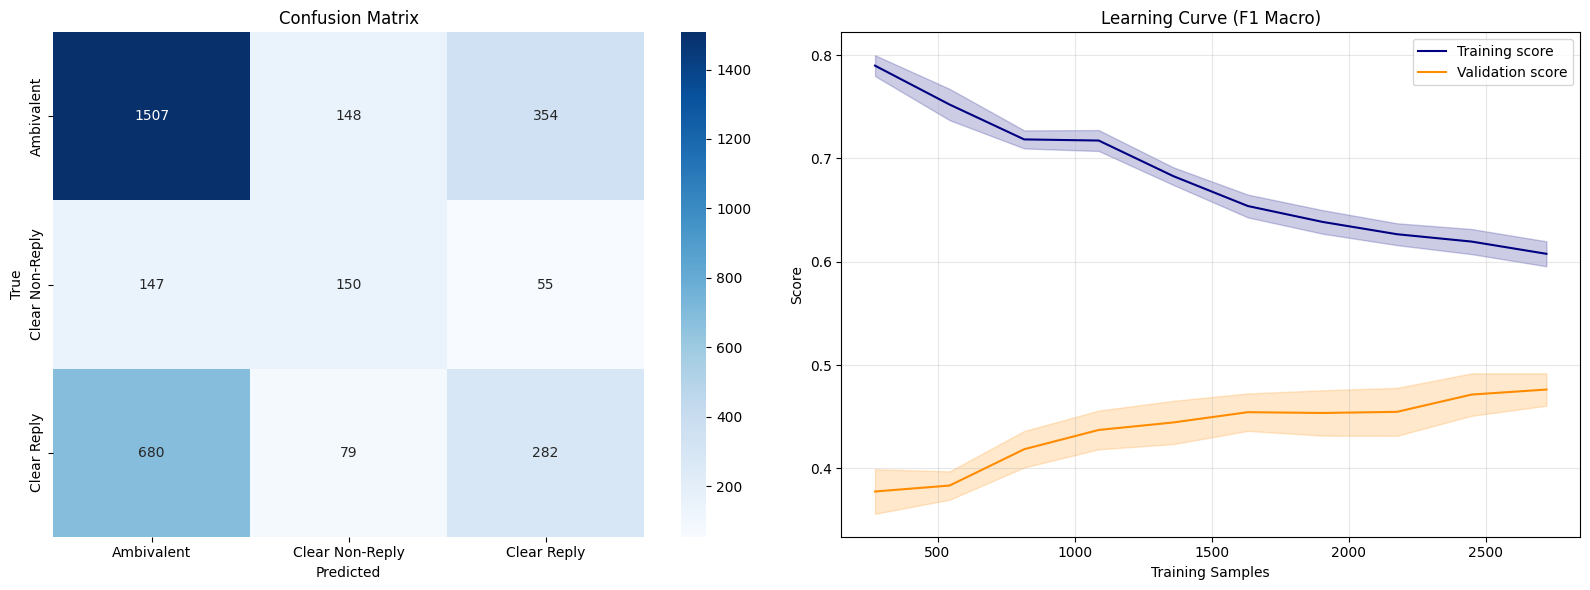

In [ ]:
#tfidf_weighted_mean
exp4_4_w2v_params= {
    "lowercase": True,     "lemmatize":True   

}

exp4_4_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=300,      
    window=2,             
    epochs=20,           
    pooling="tfidf_weighted_mean"
)

exp4_4_w2v = ExperimentTracker(
    experiment_name="tfidf_weighted_mean w2v",
    model_search_func=gridsearch_logistic,
    vectorizer=exp4_4_w2v_vectorizer,
    clean_func=clean_text
)

exp4_4_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp4_4_w2v_params
)

exp4_4_w2v.evaluator.plot_all()



#### Window size
Increasing the window size did not improve performance. This configuration achieved an F1-macro score of **0.4942 ± 0.0108** and an F1-weighted score of **0.5583 ± 0.0034**, which are slightly lower than those of the best previous Word2Vec settings.

This suggests that using a wider context window does not provide additional useful information for this task and may instead introduce more noise into the learned word representations.

--- Starting Experiment: Window_size(3)_w2v ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Best Parameters:
{'C': 30, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.4942

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5700 ± 0.0081
Precision macro     : 0.4942 ± 0.0126
Precision weighted  : 0.5558 ± 0.0032
Recall macro        : 0.5044 ± 0.0139
Recall weighted     : 0.5700 ± 0.0081
F1 macro            : 0.4942 ± 0.0108
F1 weighted         : 0.5583 ± 0.0034

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.72      0.68      2009
Clear Non-Reply       0.41      0.49      0.45       352
    Clear Reply       0.42      0.31      0.35      1041

       accuracy                           0.57      3402
      macro avg       0.49      0.50      0.49      3402
   weighted a

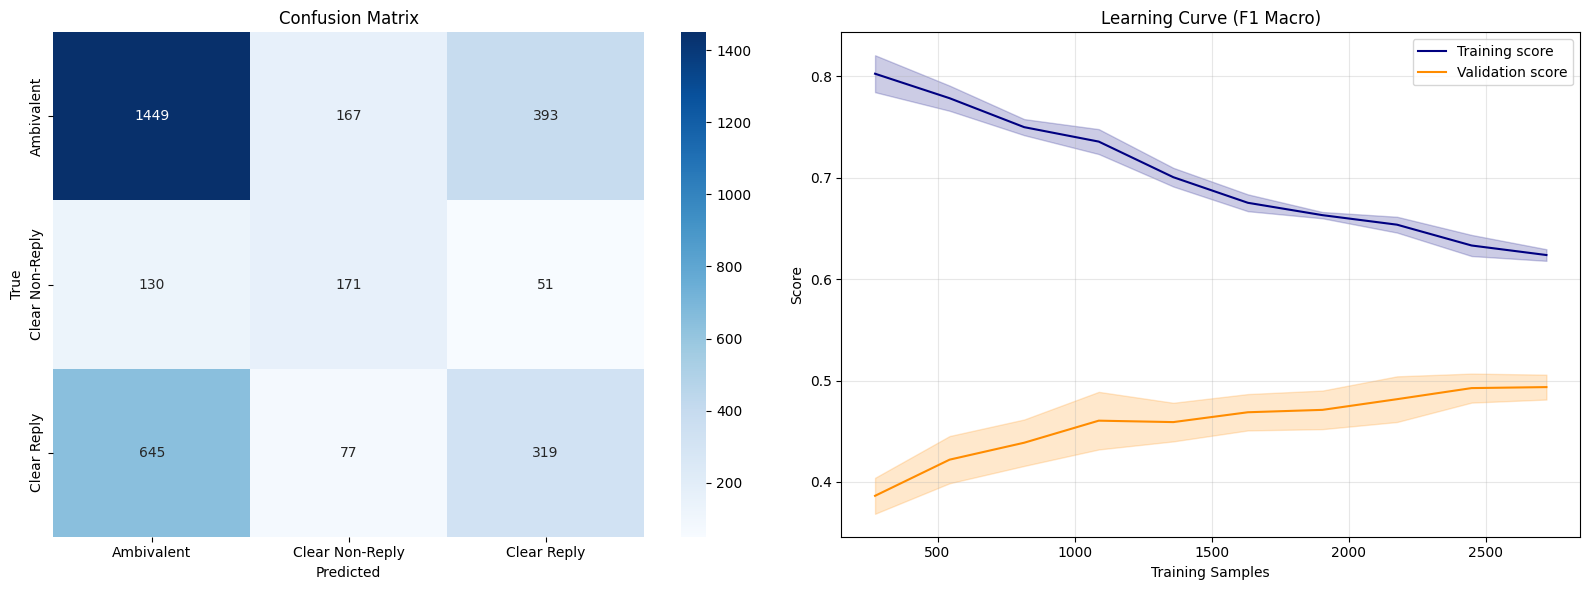

In [ ]:
#window size 3
exp4_5_w2v_params= {
    "lowercase": True, "lemmatize":True   

}

exp4_5_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=300,     
    window=3,             
    epochs=20, 
    pooling="mean"
)

exp4_5_w2v = ExperimentTracker(
    experiment_name="Window_size(3)_w2v",
    model_search_func=gridsearch_logistic,
    vectorizer=exp4_5_w2v_vectorizer,
    clean_func=clean_text
)

exp4_5_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp4_5_w2v_params
)

exp4_5_w2v.evaluator.plot_all()



#### Combine model


Finally, a combined Word2Vec configuration was tested using lemmatization, vector_size = 500, and window = 2. This configuration achieved the best performance among the examined Word2Vec settings, with an F1-macro score of **0.5050 ± 0.0128** and an F1-weighted score of **0.5723 ± 0.0055**. Although the improvement over the previous configurations is not very large, the results indicate that combining these adjustments leads to the most effective Word2Vec representation for this classification task. 


--- Starting Experiment: Combine model w2v ---
1. Cleaning text...
2. Vectorization using Word2VecAnalyzer...

3. Training Model & Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 


Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Best CV Score:
0.5050

4. Cross-Validation Evaluation...

Running 5-fold Cross-Validation...

Results (Mean ± Std)
----------------------------------------------------------------------
Accuracy            : 0.5923 ± 0.0081
Precision macro     : 0.5178 ± 0.0156
Precision weighted  : 0.5729 ± 0.0064
Recall macro        : 0.5131 ± 0.0162
Recall weighted     : 0.5923 ± 0.0081
F1 macro            : 0.5050 ± 0.0128
F1 weighted         : 0.5723 ± 0.0055

Classification Report
----------------------------------------------------------------------
                 precision    recall  f1-score   support

     Ambivalent       0.65      0.77      0.71      2009
Clear Non-Reply       0.44      0.49      0.46       352
    Clear Reply       0.46      0.28      0.35      1041

       accuracy                           0.59      3402
      macro avg       0.52      0.51      0.51      3402
   weighted a

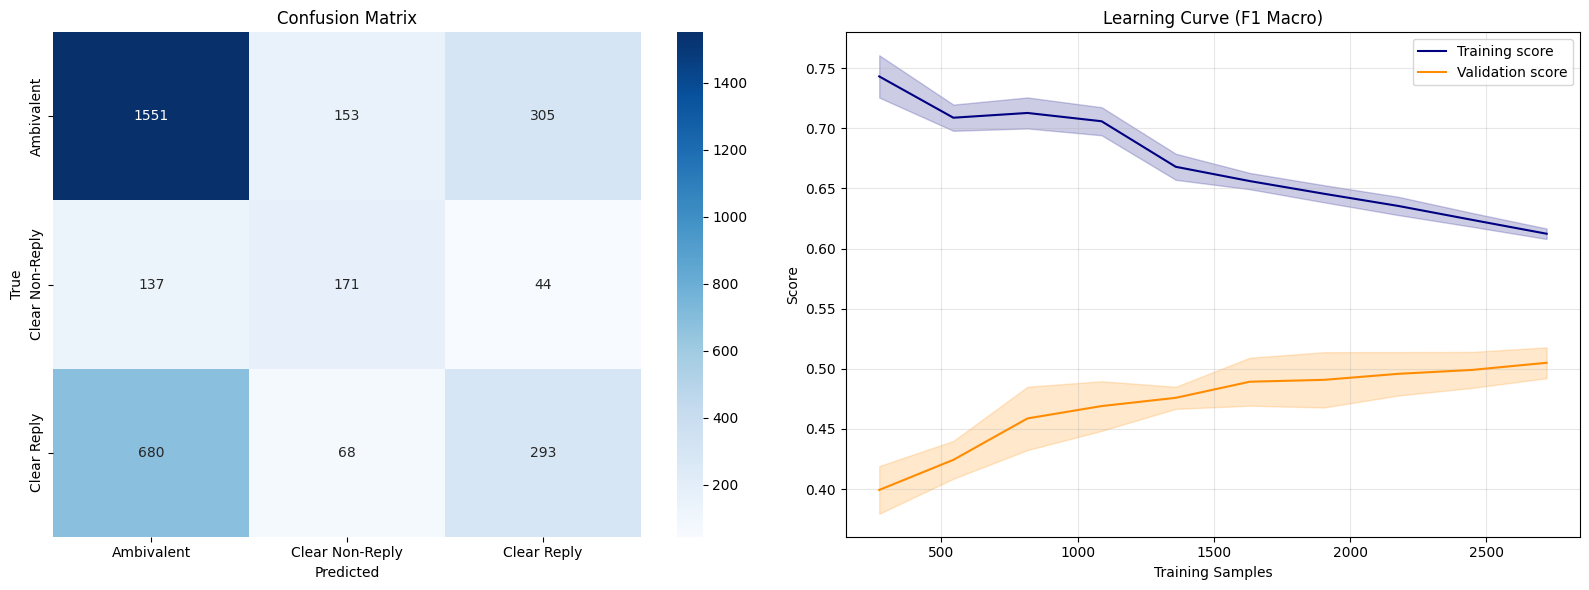

In [ ]:
# Vector size 500
exp4_7_w2v_params= {
    "lowercase": True,     "lemmatize":True      
}


exp4_7_w2v_vectorizer = Word2VecAnalyzer(
    text_column="text",
    vector_size=500,      
    window=2,             
    epochs=20,           
    pooling="mean"
)

exp4_7_w2v = ExperimentTracker(
    experiment_name="Combine model w2v",
    model_search_func=gridsearch_logistic,
    vectorizer=exp4_7_w2v_vectorizer,
    clean_func=clean_text
)


exp4_7_w2v.run_training(
    training_data=training_data, 
    text_col="text", 
    label_col="clarity_label", 
    clean_params=exp4_7_w2v_params
)

exp4_7_w2v.evaluator.plot_all()



Conclusion for Word2Vec

The Word2Vec experiments show that this approach does not lead to strong improvements in classification performance. Most of the tested configurations produced results that were very close to each other, and none of them clearly outperformed the baseline by a meaningful margin.

Among the examined settings, lemmatization gave the most competitive results, while changes such as stop-word removal, skip-gram, alternative pooling strategies, and larger window sizes did not improve performance. Increasing the embedding size and combining multiple adjustments also resulted in scores that were very similar to the previous experiments.

In addition, the confusion matrices remain broadly similar across the Word2Vec experiments. The model continues to classify the Ambivalent class more accurately, while Clear Non-Reply and Clear Reply remain more difficult to distinguish. This shows that the same class-separation problem persists across the different Word2Vec settings.

At the same time, the learning curves suggest a different behavior from TF-IDF. Although Word2Vec does not achieve higher scores, the gap between training and validation performance appears smaller, indicating less pronounced overfitting. However, since both curves remain relatively low, this also suggests that the model is not able to capture enough discriminative information for the task.

# Final predict on the best model
Overall, the Word2Vec experiments show that preprocessing and model configuration have a measurable impact on performance. Among the tested variants, lemmatization consistently improved the representation, while aggressive stopword removal and alternative pooling strategies such as max pooling or tfidf-weighted mean reduced performance. The best Word2Vec configuration was the lemmatized model with vector_size=500 and window=3, which achieved the highest macro-F1 score among the Word2Vec experiments. Even though the TF-IDF models achieved better macro-F1 and weighted-F1 scores, we selected this model as the final one because the learning curves in the TF-IDF experiments suggested overfitting. For this reason, the Word2Vec model was considered a more stable choice for final prediction.

In [ ]:
import pandas as pd

#  clean test text with same parameters
clean_test_series = test_data["text"].apply(
    lambda x: clean_text(x, **exp4_7_w2v_params)
)

test_input = pd.DataFrame({
    exp4_7_w2v.vectorizer.text_column: clean_test_series
})

X_test_final = exp4_7_w2v.vectorizer.transform(test_input)

test_predictions = exp4_7_w2v.best_model.predict(X_test_final)

submission = pd.DataFrame({
    "Id": range(len(test_predictions)),
    "Predicted": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("submission created successfully")
print(submission.head())

submission_Margarita_Orfanidi.csv created successfully
   Id   Predicted
0   0  Ambivalent
1   1  Ambivalent
2   2  Ambivalent
3   3  Ambivalent
4   4  Ambivalent
